# This code is to compare the data collected from 2 different hardwares, 3080 and 4090

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cur_dir = os.getcwd()
print(cur_dir)

parent_dir = os.path.dirname(cur_dir)
print(parent_dir)

file3080_dir = os.path.join(parent_dir, '3080', 'CNNModelsData')
file4090_dir = os.path.join(parent_dir, '4090', 'CNNModelsData')

print(file3080_dir)
print(file4090_dir)

/Users/dtjgp/Projects/GreenAI/GPU_Performance/Cloud/AutoDL_Version2/Comparision_3080_4090
/Users/dtjgp/Projects/GreenAI/GPU_Performance/Cloud/AutoDL_Version2
/Users/dtjgp/Projects/GreenAI/GPU_Performance/Cloud/AutoDL_Version2/3080/CNNModelsData
/Users/dtjgp/Projects/GreenAI/GPU_Performance/Cloud/AutoDL_Version2/4090/CNNModelsData


## Comparison of 3080 and 4090

In [3]:
def get_epoch_energy(npyfile):
    energy_consumption = np.zeros((npyfile.shape[0],1))
    for epoch in range(npyfile.shape[0]):
        energy_consumption[epoch] = 0 
        for batch in range(npyfile.shape[1]):
            energy_consumption[epoch] += (npyfile[epoch][batch][1] - npyfile[epoch][batch][0]) * npyfile[epoch][batch][2]
    return energy_consumption

In [4]:
# plot the energy data for the 3080 and 4090 models select the alexnet model, resnet18 model resnet34 model, googlenet_origin model and vgg11 model and mobilenetv1 model
dataset = ['fashion_mnist', 'cifar100']
model = ['alexnet', 'resnet18', 'resnet34', 'googlenet_origin', 'vgg11', 'mobilenetv2']
sample_folder = 'E5_B128_R0_SR2'

# load each step energy consumption to sum up to get each epoch energy consumption in Training process
def readfiles(hardware, model, dataset, sample_folder, file_dir):
    file_dir = os.path.join(hardware, model, dataset, sample_folder)
    # read the energy consumption npy files from the directory
    to_device_energy = np.load(os.path.join(file_dir, 'to_device_energy.npy'), allow_pickle=True)
    forward_energy = np.load(os.path.join(file_dir, 'forward_energy.npy'), allow_pickle=True)
    loss_energy = np.load(os.path.join(file_dir, 'loss_energy.npy'), allow_pickle=True)
    backward_energy = np.load(os.path.join(file_dir, 'backward_energy.npy'), allow_pickle=True)
    optimize_energy = np.load(os.path.join(file_dir, 'optimize_energy.npy'), allow_pickle=True)
    # sum up the energy consumption for each step
    to_device_total_energy = get_epoch_energy(to_device_energy)
    forward_total_energy = get_epoch_energy(forward_energy)
    loss_total_energy = get_epoch_energy(loss_energy)
    backward_total_energy = get_epoch_energy(backward_energy)
    optimize_total_energy = get_epoch_energy(optimize_energy)
    # sum up the energy consumption for each epoch
    total_energy = to_device_total_energy + forward_total_energy + loss_total_energy + backward_total_energy + optimize_total_energy
    return total_energy




# 3080 alexnet
alexnet3080_f = pd.read_csv(os.path.join(file3080_dir, model[0], dataset[0], sample_folder, 'labeled_energy_data.csv'))
alexnet3080_f_train = readfiles(file3080_dir, model[0], dataset[0], sample_folder, file3080_dir)
alexnet3080_c = pd.read_csv(os.path.join(file3080_dir, model[0], dataset[1], sample_folder, 'labeled_energy_data.csv'))
alexnet3080_c_train = readfiles(file3080_dir, model[0], dataset[1], sample_folder, file3080_dir)

# 3080 resnet18
resnet183080_f = pd.read_csv(os.path.join(file3080_dir, model[1], dataset[0], sample_folder, 'labeled_energy_data.csv'))
resnet183080_f_train = readfiles(file3080_dir, model[1], dataset[0], sample_folder, file3080_dir)
resnet183080_c = pd.read_csv(os.path.join(file3080_dir, model[1], dataset[1], sample_folder, 'labeled_energy_data.csv'))
resnet183080_c_train = readfiles(file3080_dir, model[1], dataset[1], sample_folder, file3080_dir)

# 4090 alexnet
alexnet4090_f = pd.read_csv(os.path.join(file4090_dir, model[0], dataset[0], sample_folder, 'labeled_energy_data.csv'))
alexnet4090_f_train = readfiles(file4090_dir, model[0], dataset[0], sample_folder, file4090_dir)
alexnet4090_c = pd.read_csv(os.path.join(file4090_dir, model[0], dataset[1], sample_folder, 'labeled_energy_data.csv'))
alexnet4090_c_train = readfiles(file4090_dir, model[0], dataset[1], sample_folder, file4090_dir)

# 4090 resnet18
resnet184090_f = pd.read_csv(os.path.join(file4090_dir, model[1], dataset[0], sample_folder, 'labeled_energy_data.csv'))
resnet184090_f_train = readfiles(file4090_dir, model[1], dataset[0], sample_folder, file4090_dir)
resnet184090_c = pd.read_csv(os.path.join(file4090_dir, model[1], dataset[1], sample_folder, 'labeled_energy_data.csv'))
resnet184090_c_train = readfiles(file4090_dir, model[1], dataset[1], sample_folder, file4090_dir)

# 3080 resnet34
resnet343080_f = pd.read_csv(os.path.join(file3080_dir, model[2], dataset[0], sample_folder, 'labeled_energy_data.csv'))
resnet343080_f_train = readfiles(file3080_dir, model[2], dataset[0], sample_folder, file3080_dir)
resnet343080_c = pd.read_csv(os.path.join(file3080_dir, model[2], dataset[1], sample_folder, 'labeled_energy_data.csv'))
resnet343080_c_train = readfiles(file3080_dir, model[2], dataset[1], sample_folder, file3080_dir)

# 4090 resnet34
resnet344090_f = pd.read_csv(os.path.join(file4090_dir, model[2], dataset[0], sample_folder, 'labeled_energy_data.csv'))
resnet344090_f_train = readfiles(file4090_dir, model[2], dataset[0], sample_folder, file4090_dir)
resnet344090_c = pd.read_csv(os.path.join(file4090_dir, model[2], dataset[1], sample_folder, 'labeled_energy_data.csv'))
resnet344090_c_train = readfiles(file4090_dir, model[2], dataset[1], sample_folder, file4090_dir)

# 3080 googlenet_origin
googlenet_origin3080_f = pd.read_csv(os.path.join(file3080_dir, model[3], dataset[0], sample_folder, 'labeled_energy_data.csv'))
googlenet_origin3080_f_train = readfiles(file3080_dir, model[3], dataset[0], sample_folder, file3080_dir)
googlenet_origin3080_c = pd.read_csv(os.path.join(file3080_dir, model[3], dataset[1], sample_folder, 'labeled_energy_data.csv'))
googlenet_origin3080_c_train = readfiles(file3080_dir, model[3], dataset[1], sample_folder, file3080_dir)

# 4090 googlenet_origin
googlenet_origin4090_f = pd.read_csv(os.path.join(file4090_dir, model[3], dataset[0], sample_folder, 'labeled_energy_data.csv'))
googlenet_origin4090_f_train = readfiles(file4090_dir, model[3], dataset[0], sample_folder, file4090_dir)
googlenet_origin4090_c = pd.read_csv(os.path.join(file4090_dir, model[3], dataset[1], sample_folder, 'labeled_energy_data.csv'))
googlenet_origin4090_c_train = readfiles(file4090_dir, model[3], dataset[1], sample_folder, file4090_dir)

# 3080 vgg11
vgg113080_f = pd.read_csv(os.path.join(file3080_dir, model[4], dataset[0], sample_folder, 'labeled_energy_data.csv'))
vgg113080_f_train = readfiles(file3080_dir, model[4], dataset[0], sample_folder, file3080_dir)
vgg113080_c = pd.read_csv(os.path.join(file3080_dir, model[4], dataset[1], sample_folder, 'labeled_energy_data.csv'))
vgg113080_c_train = readfiles(file3080_dir, model[4], dataset[1], sample_folder, file3080_dir)

# 4090 vgg11
vgg114090_f = pd.read_csv(os.path.join(file4090_dir, model[4], dataset[0], sample_folder, 'labeled_energy_data.csv'))
vgg114090_f_train = readfiles(file4090_dir, model[4], dataset[0], sample_folder, file4090_dir)
vgg114090_c = pd.read_csv(os.path.join(file4090_dir, model[4], dataset[1], sample_folder, 'labeled_energy_data.csv'))
vgg114090_c_train = readfiles(file4090_dir, model[4], dataset[1], sample_folder, file4090_dir)

# 3080 mobilenetv1
mobilenetv23080_f = pd.read_csv(os.path.join(file3080_dir, model[5], dataset[0], sample_folder, 'labeled_energy_data.csv'))
mobilenetv23080_f_train = readfiles(file3080_dir, model[5], dataset[0], sample_folder, file3080_dir)
mobilenetv23080_c = pd.read_csv(os.path.join(file3080_dir, model[5], dataset[1], sample_folder, 'labeled_energy_data.csv'))
mobilenetv23080_c_train = readfiles(file3080_dir, model[5], dataset[1], sample_folder, file3080_dir)

# 4090 mobilenetv1
mobilenetv24090_f = pd.read_csv(os.path.join(file4090_dir, model[5], dataset[0], sample_folder, 'labeled_energy_data.csv'))
mobilenetv24090_f_train = readfiles(file4090_dir, model[5], dataset[0], sample_folder, file4090_dir)
mobilenetv24090_c = pd.read_csv(os.path.join(file4090_dir, model[5], dataset[1], sample_folder, 'labeled_energy_data.csv'))
mobilenetv24090_c_train = readfiles(file4090_dir, model[5], dataset[1], sample_folder, file4090_dir)



FileNotFoundError: [Errno 2] No such file or directory: '/Users/dtjgp/Projects/GreenAI/GPU_Performance/Cloud/AutoDL_Version2/3080/CNNModelsData/alexnet/fashion_mnist/E5_B128_R0_SR2/labeled_energy_data.csv'

In [ ]:
# Create a color map and marker map for the steps
step_colors = {
    'idle': 'gray',
    'to_device': 'blue',
    'forward': 'green',
    'loss': 'red',
    'backward': 'purple',
    'optimize': 'orange'
}
step_markers = {
    'idle': 'o',
    'to_device': 's',
    'forward': '^',
    'loss': 'D',
    'backward': 'x',
    'optimize': 'P'
}

In [ ]:
# def plot_energy_data(labeled_energy_data, step_colors, step_markers, model_name, plot_folder):
#     # Plot the data with a larger figure size
#     fig, ax = plt.subplots(figsize=(12, 6))

#     # Plot each step with a different marker
#     for step in step_colors.keys():
#         step_data = labeled_energy_data[labeled_energy_data['step'] == step]
#         if step != 'idle':
#             ax.scatter(step_data['timestamp'], step_data['power_in_watts'], color=step_colors[step], label=step, s=5, marker=step_markers[step])

#     ax.set_xlabel(f'Timestamp Across All Samples in {model_name}')
#     ax.set_ylabel('Power in Watts')
#     ax.set_title(f'Energy Data of Each Sample in {model_name}')
#     ax.legend()
#     plt.show()
#     # save the figure, to a specific directory
#     plt.savefig(os.path.join(plot_folder, f'energy_data of {model_name}.png'))

In [ ]:
# change the time value in thet timestamp to the index of the data
def change_timestamp_to_index(labeled_energy_data):
    labeled_energy_data['timestamp'] = labeled_energy_data['timestamp'] - labeled_energy_data['timestamp'].iloc[0]
    return labeled_energy_data

# remove the idle step in the energy data
def remove_idle_step(labeled_energy_data):
    labeled_energy_data = labeled_energy_data[labeled_energy_data['step'] != 'idle']
    return labeled_energy_data

# plot the energy data for each step in the training process
def cleandata(labeled_energy_data,  model_name):
    # first to change the timestamp to index
    labeled_energy_data = change_timestamp_to_index(labeled_energy_data)

    # remove the idle step
    labeled_energy_data = remove_idle_step(labeled_energy_data)

    # reset the index of the data
    labeled_energy_data = labeled_energy_data.reset_index(drop=True)

    return labeled_energy_data
    # # Plot the data with a larger figure size
    # fig, ax = plt.subplots(figsize=(12, 6))
    
    # # Plot each step in different color
    # for step in step_colors.keys():
    #     step_data = labeled_energy_data[labeled_energy_data['step'] == step]
    #     plt.scatter(step_data['timestamp'], step_data['power_in_watts'], alpha=0.7)

    # ax.set_xlabel(f'Time Step in {model_name}')
    # ax.set_ylabel('Power in Watts')
    # ax.set_title(f'Energy Data of Each Sample in {model_name}')
    # ax.legend()
    # plt.show()


# clean the data for each model
alexnet3080_f = cleandata(alexnet3080_f, 'alexnet3080_f')
alexnet3080_c = cleandata(alexnet3080_c, 'alexnet3080_c')
resnet183080_f = cleandata(resnet183080_f, 'resnet183080_f')
resnet183080_c = cleandata(resnet183080_c, 'resnet183080_c')
alexnet4090_f = cleandata(alexnet4090_f, 'alexnet4090_f')
alexnet4090_c = cleandata(alexnet4090_c, 'alexnet4090_c')
resnet184090_f = cleandata(resnet184090_f, 'resnet184090_f')
resnet184090_c = cleandata(resnet184090_c, 'resnet184090_c')
resnet343080_f = cleandata(resnet343080_f, 'resnet343080_f')
resnet343080_c = cleandata(resnet343080_c, 'resnet343080_c')
resnet344090_f = cleandata(resnet344090_f, 'resnet344090_f')
resnet344090_c = cleandata(resnet344090_c, 'resnet344090_c')
googlenet_origin3080_f = cleandata(googlenet_origin3080_f, 'googlenet_origin3080_f')
googlenet_origin3080_c = cleandata(googlenet_origin3080_c, 'googlenet_origin3080_c')
googlenet_origin4090_f = cleandata(googlenet_origin4090_f, 'googlenet_origin4090_f')
googlenet_origin4090_c = cleandata(googlenet_origin4090_c, 'googlenet_origin4090_c')
vgg113080_f = cleandata(vgg113080_f, 'vgg113080_f')
vgg113080_c = cleandata(vgg113080_c, 'vgg113080_c')
vgg114090_f = cleandata(vgg114090_f, 'vgg114090_f')
vgg114090_c = cleandata(vgg114090_c, 'vgg114090_c')
mobilenetv23080_f = cleandata(mobilenetv23080_f, 'mobilenetv23080_f')
mobilenetv23080_c = cleandata(mobilenetv23080_c, 'mobilenetv23080_c')
mobilenetv24090_f = cleandata(mobilenetv24090_f, 'mobilenetv24090_f')
mobilenetv24090_c = cleandata(mobilenetv24090_c, 'mobilenetv24090_c')



In [ ]:
# Create a figure
# plt.figure(figsize=(15,12))
# Set the style for a professional look
plt.style.use('seaborn-v0_8-paper')
# Set all fonts to serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']  # Specify Times New Roman as the serif font
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25 
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25

# Professional color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
         '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

In [ ]:
# # Create a figure
# plt.figure(figsize=(15, 8))

# for step in step_colors.keys():
#     step_data1 = alexnet3080_f[alexnet3080_f['step'] == step]
#     if step != 'idle':
#         plt.scatter(step_data1['timestamp'], step_data1['power_in_watts'], color=step_colors[step], label=step, s=5)
    
#     # step_data2 = alexnet3080_c[alexnet3080_c['step'] == step]
#     # # if step != 'idle':
#     # plt.scatter(step_data2['timestamp'], step_data2['power_in_watts'], color=step_colors[step], label=step, s=5, marker=step_markers[step])

# plt.xlabel('Timestamp Across All Samples in Alexnet')
# plt.ylabel('Power in Watts')
# plt.title('Energy Data of Each Sample in Alexnet')
# plt.legend()
# plt.show()

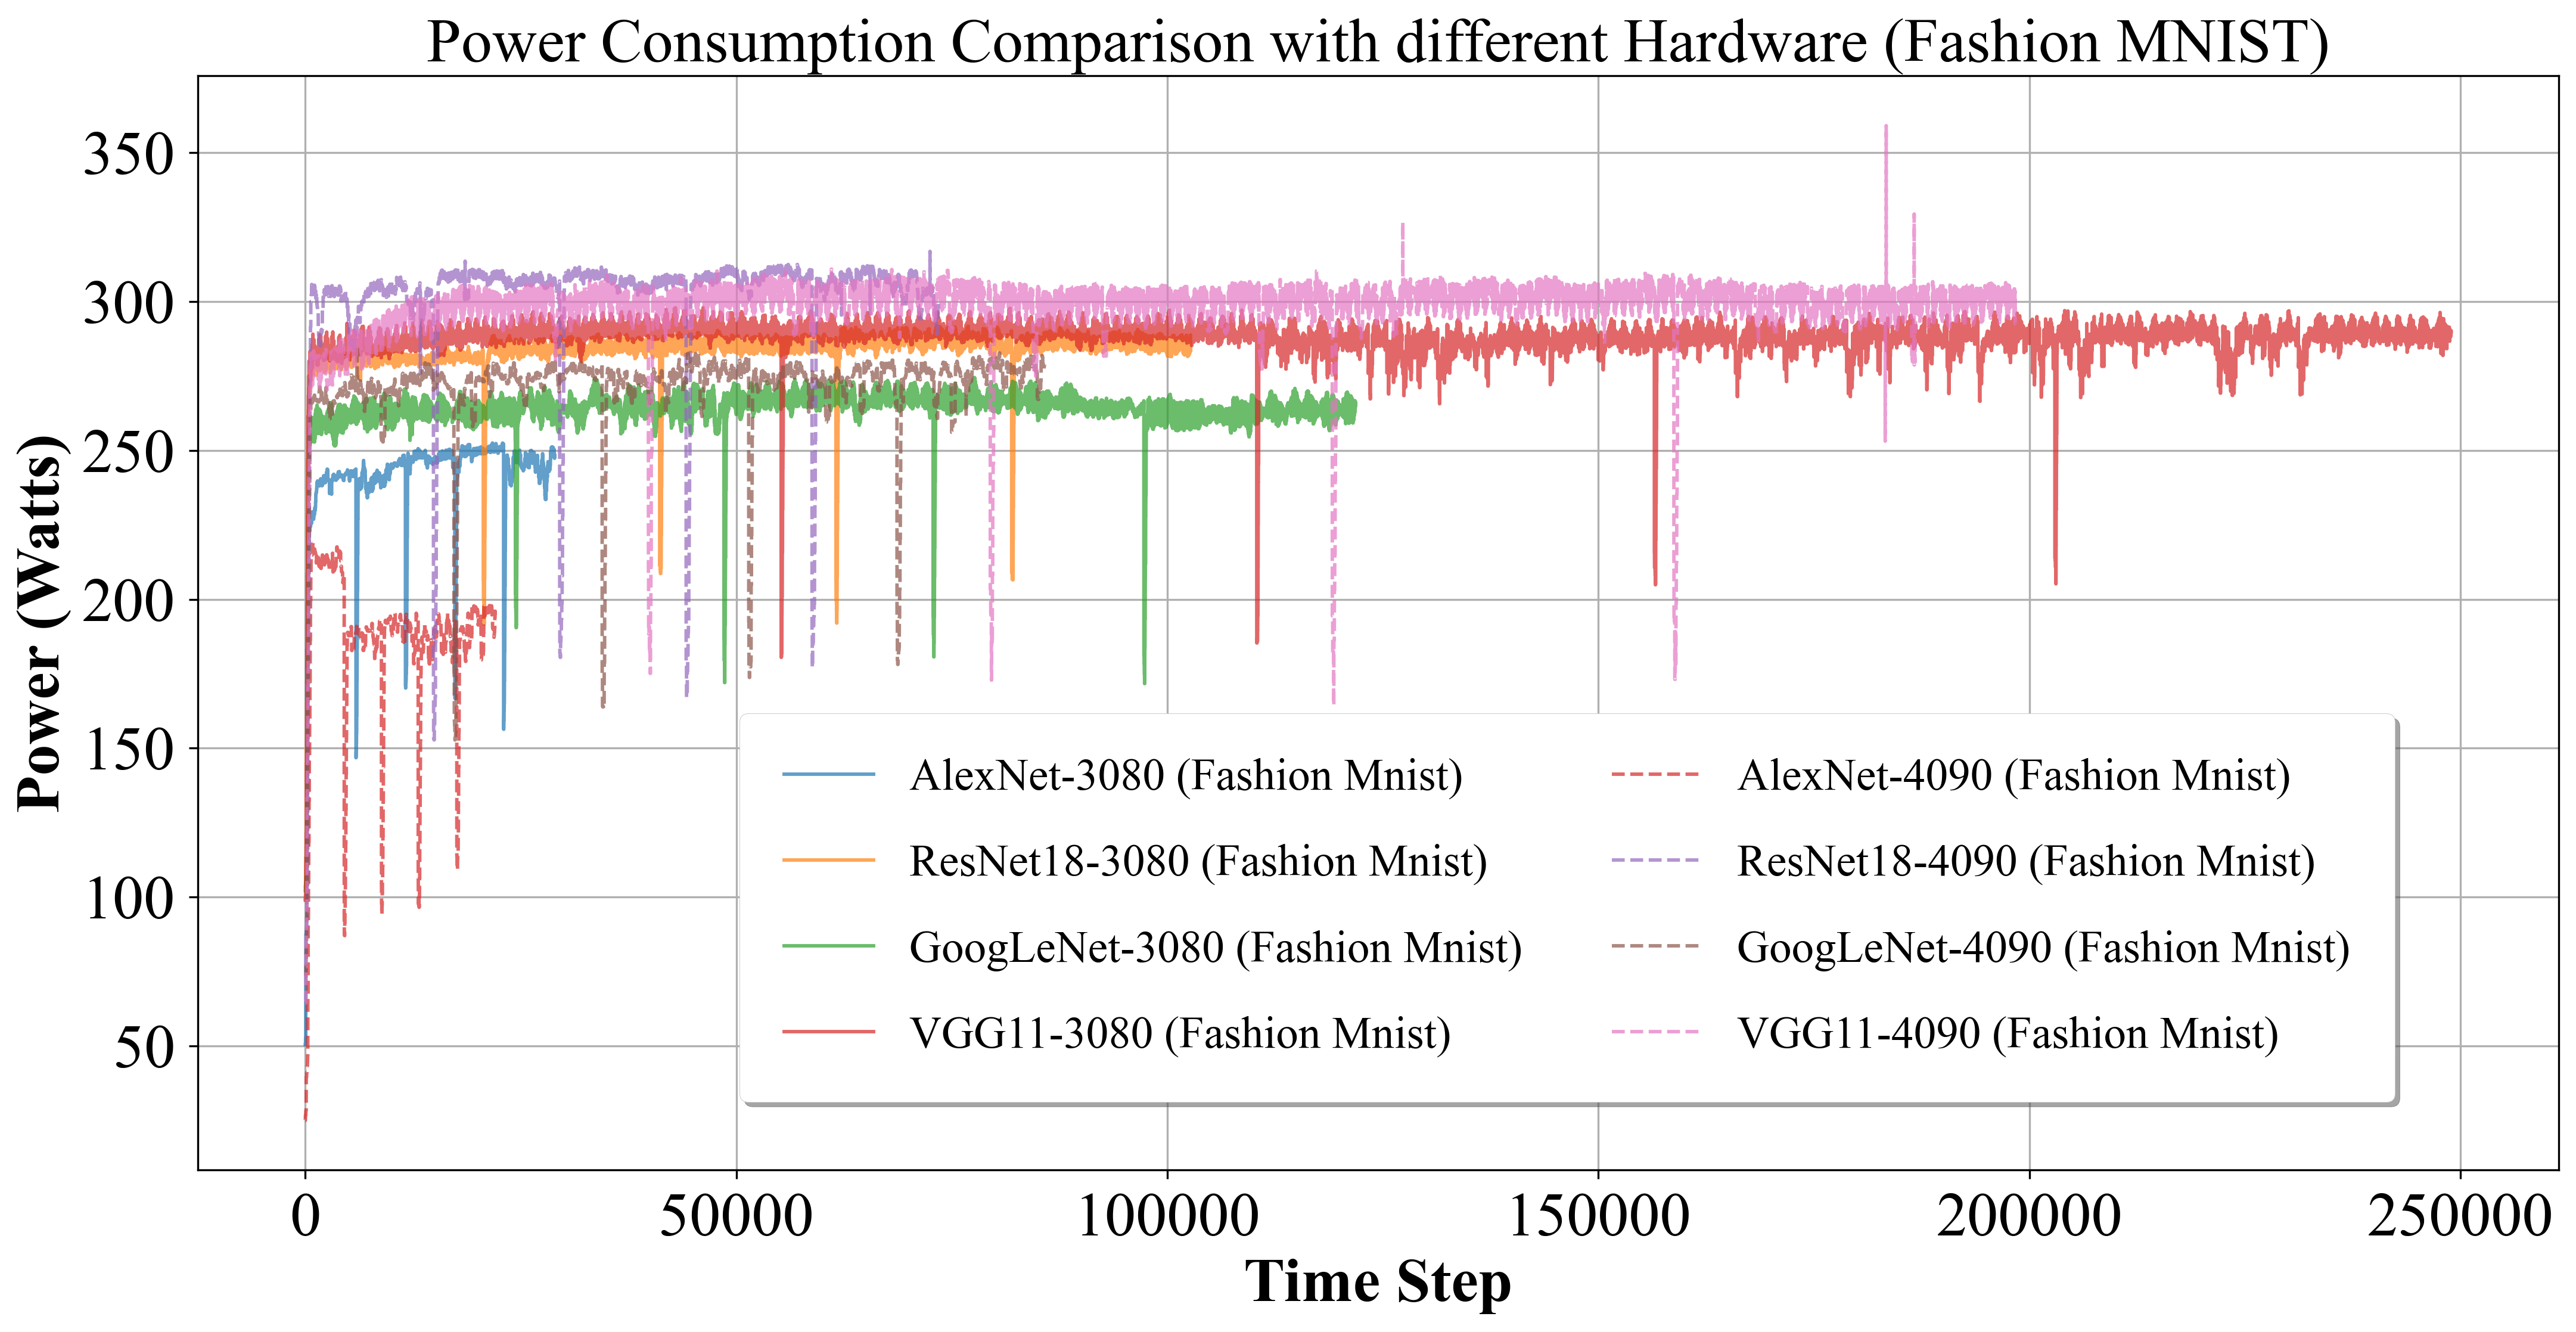

In [ ]:
# Fig 1
# Create a figure
plt.figure(figsize=(15, 8), dpi=300)

# Plot data for 3080 models
plt.plot(alexnet3080_f['power_in_watts'][:], label='AlexNet-3080 (Fashion Mnist)', alpha=0.7, color=colors[0])
# plt.plot(alexnet3080_c['power_in_watts'][:], label='alexnet3080_cifar100', alpha=0.7)
plt.plot(resnet183080_f['power_in_watts'][:], label='ResNet18-3080 (Fashion Mnist)', alpha=0.7, color=colors[1])
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='GoogLeNet-3080 (Fashion Mnist)', alpha=0.7, color=colors[2])
plt.plot(vgg113080_f['power_in_watts'][:], label='VGG11-3080 (Fashion Mnist)', alpha=0.7, color=colors[3])


# Plot data for 4090 models with dashed lines
plt.plot(alexnet4090_f['power_in_watts'][:], label='AlexNet-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[3])
# plt.plot(alexnet4090_c['power_in_watts'][:50000], label='alexnet4090_cifar100', alpha=0.7, linestyle='--')
plt.plot(resnet184090_f['power_in_watts'][:], label='ResNet18-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[4])
plt.plot(googlenet_origin4090_f['power_in_watts'][:], label='GoogLeNet-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[5])
plt.plot(vgg114090_f['power_in_watts'][:], label='VGG11-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[6])

# Customize the plot with professional styling
plt.xlabel('Time Steps', fontfamily='serif', fontweight='bold')
plt.ylabel('Power Consumption (Watts)', fontfamily='serif', fontweight='bold')

# Customize the plot
plt.xlabel('Time Step', fontfamily='serif')
plt.ylabel('Power (Watts)', fontfamily='serif')
plt.title('Power Consumption Comparison with different Hardware (Fashion MNIST)', fontfamily='serif')
# Customize legend - moved to bottom center
plt.legend(loc='center', bbox_to_anchor=(0.58, 0.24),
          frameon=True, fancybox=True, shadow=True,
          borderpad=1, labelspacing=1, ncol=2, prop={'family': 'serif'})
plt.grid(True)

plt.tight_layout()
plt.show()


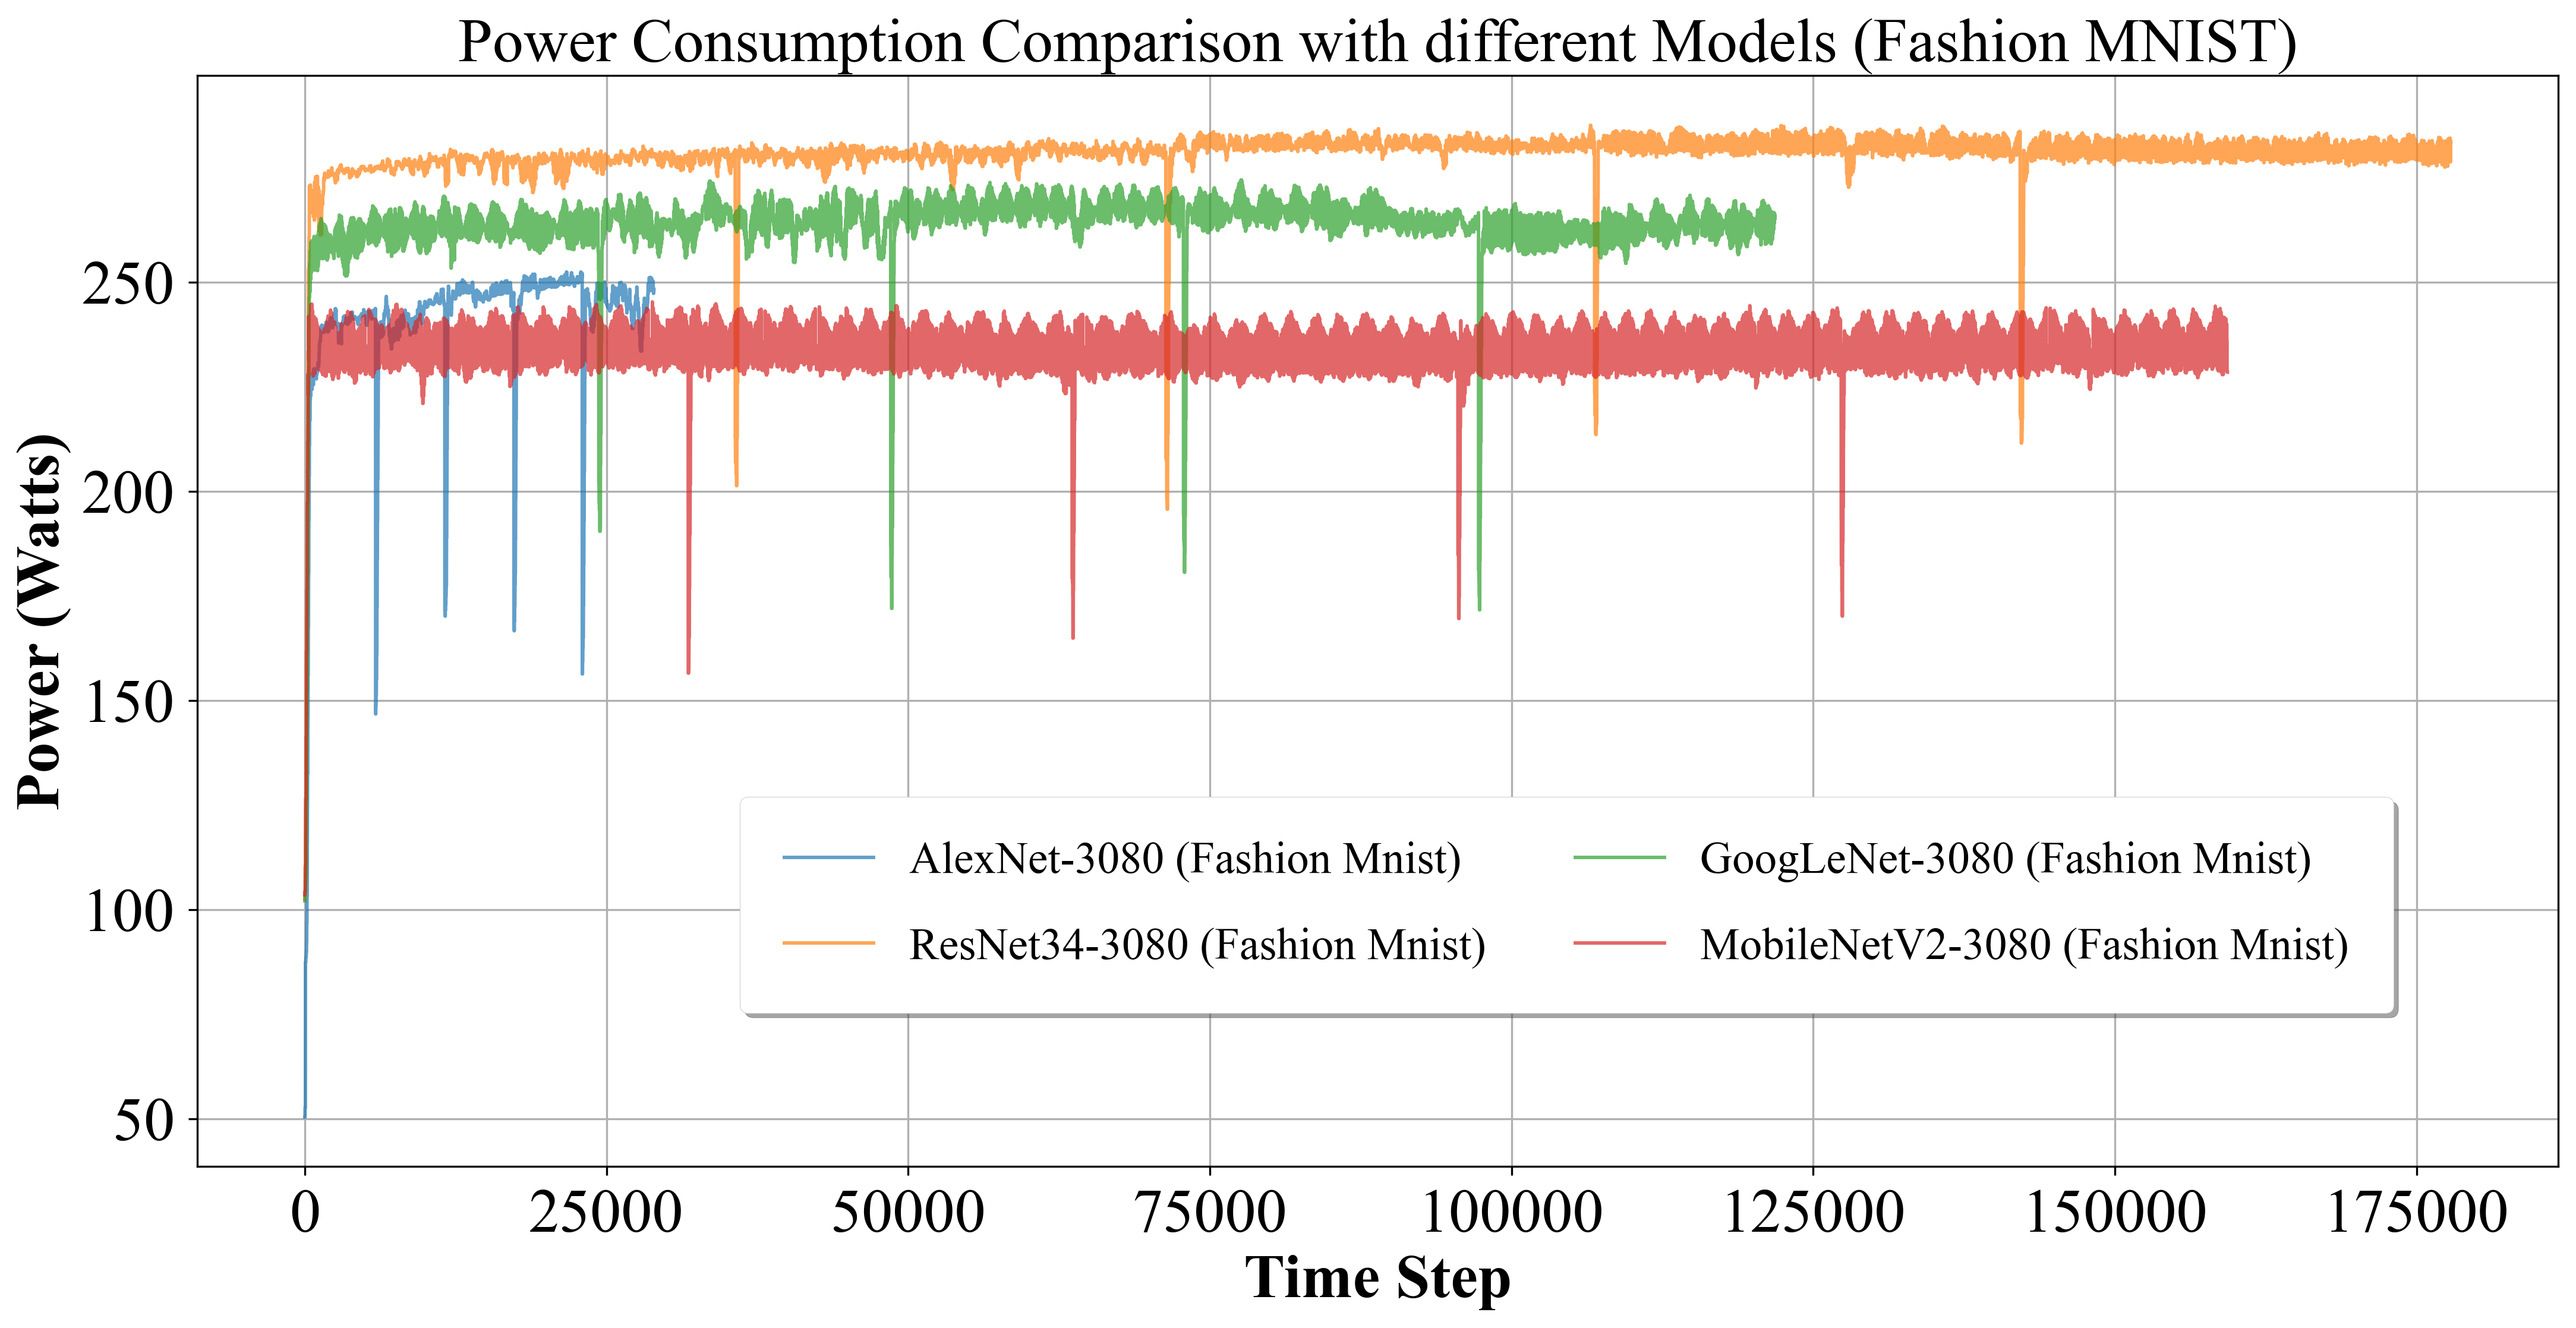

In [ ]:
# Fig 2
# Create a figure
plt.figure(figsize=(15, 8), dpi=300)

# Plot data for 3080 models
plt.plot(alexnet3080_f['power_in_watts'][:], label='AlexNet-3080 (Fashion Mnist)', alpha=0.7, color=colors[0])
# plt.plot(alexnet3080_c['power_in_watts'][:], label='alexnet3080_cifar100', alpha=0.7)
plt.plot(resnet343080_f['power_in_watts'][:], label='ResNet34-3080 (Fashion Mnist)', alpha=0.7, color=colors[1])
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='GoogLeNet-3080 (Fashion Mnist)', alpha=0.7, color=colors[2])
plt.plot(mobilenetv23080_f['power_in_watts'][:], label='MobileNetV2-3080 (Fashion Mnist)', alpha=0.7, color=colors[3])


# Plot data for 4090 models with dashed lines
# plt.plot(alexnet4090_f['power_in_watts'][:], label='AlexNet-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[3])
# # plt.plot(alexnet4090_c['power_in_watts'][:50000], label='alexnet4090_cifar100', alpha=0.7, linestyle='--')
# plt.plot(resnet184090_f['power_in_watts'][:], label='ResNet18-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[4])
# plt.plot(googlenet_origin4090_f['power_in_watts'][:], label='GoogLeNet-4090 (Fashion Mnist)', alpha=0.7, linestyle='--', color=colors[5])

# Customize the plot with professional styling
plt.xlabel('Time Steps', fontfamily='serif', fontweight='bold')
plt.ylabel('Power Consumption (Watts)', fontfamily='serif', fontweight='bold')

# Customize the plot
plt.xlabel('Time Step', fontfamily='serif')
plt.ylabel('Power (Watts)', fontfamily='serif')
plt.title('Power Consumption Comparison with different Models (Fashion MNIST)', fontfamily='serif')
# Customize legend - moved to bottom center
plt.legend(loc='center', bbox_to_anchor=(0.58, 0.24),
          frameon=True, fancybox=True, shadow=True,
          borderpad=1, labelspacing=1, ncol=2, prop={'family': 'serif'})
plt.grid(True)

plt.tight_layout()
plt.show()


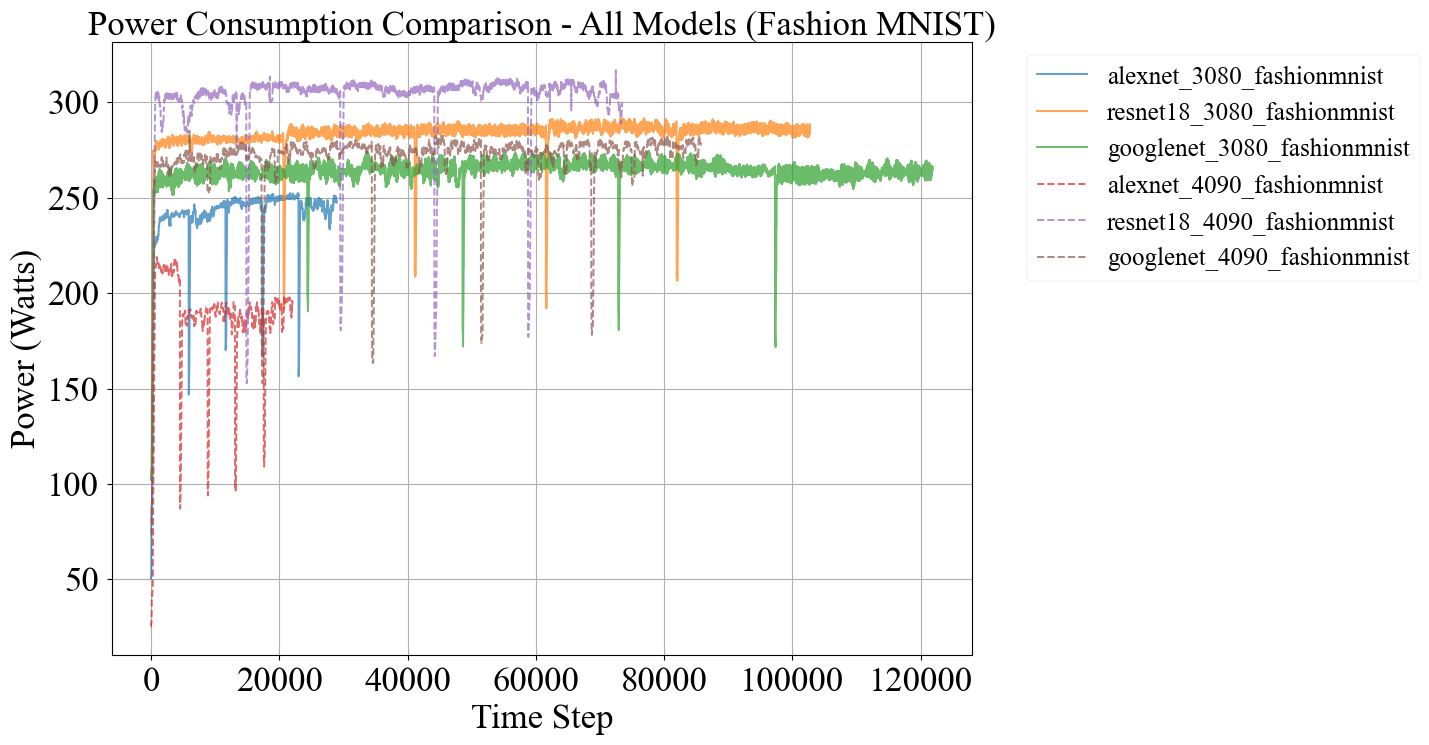

In [ ]:
# Create a figure
plt.figure(figsize=(15, 8))

# Plot data for 3080 models
plt.plot(alexnet3080_f['power_in_watts'][:], label='alexnet_3080_fashionmnist', alpha=0.7)
# plt.plot(alexnet3080_c['power_in_watts'][:], label='alexnet3080_cifar100', alpha=0.7)
plt.plot(resnet183080_f['power_in_watts'][:], label='resnet18_3080_fashionmnist', alpha=0.7)
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='googlenet_3080_fashionmnist', alpha=0.7)

# Plot data for 4090 models with dashed lines
plt.plot(alexnet4090_f['power_in_watts'][:], label='alexnet_4090_fashionmnist', alpha=0.7, linestyle='--')
# plt.plot(alexnet4090_c['power_in_watts'][:50000], label='alexnet4090_cifar100', alpha=0.7, linestyle='--')
plt.plot(resnet184090_f['power_in_watts'][:], label='resnet18_4090_fashionmnist', alpha=0.7, linestyle='--')
plt.plot(googlenet_origin4090_f['power_in_watts'][:], label='googlenet_4090_fashionmnist', alpha=0.7, linestyle='--')


# Customize the plot
plt.xlabel('Time Step')
plt.ylabel('Power (Watts)')
plt.title('Power Consumption Comparison - All Models (Fashion MNIST)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


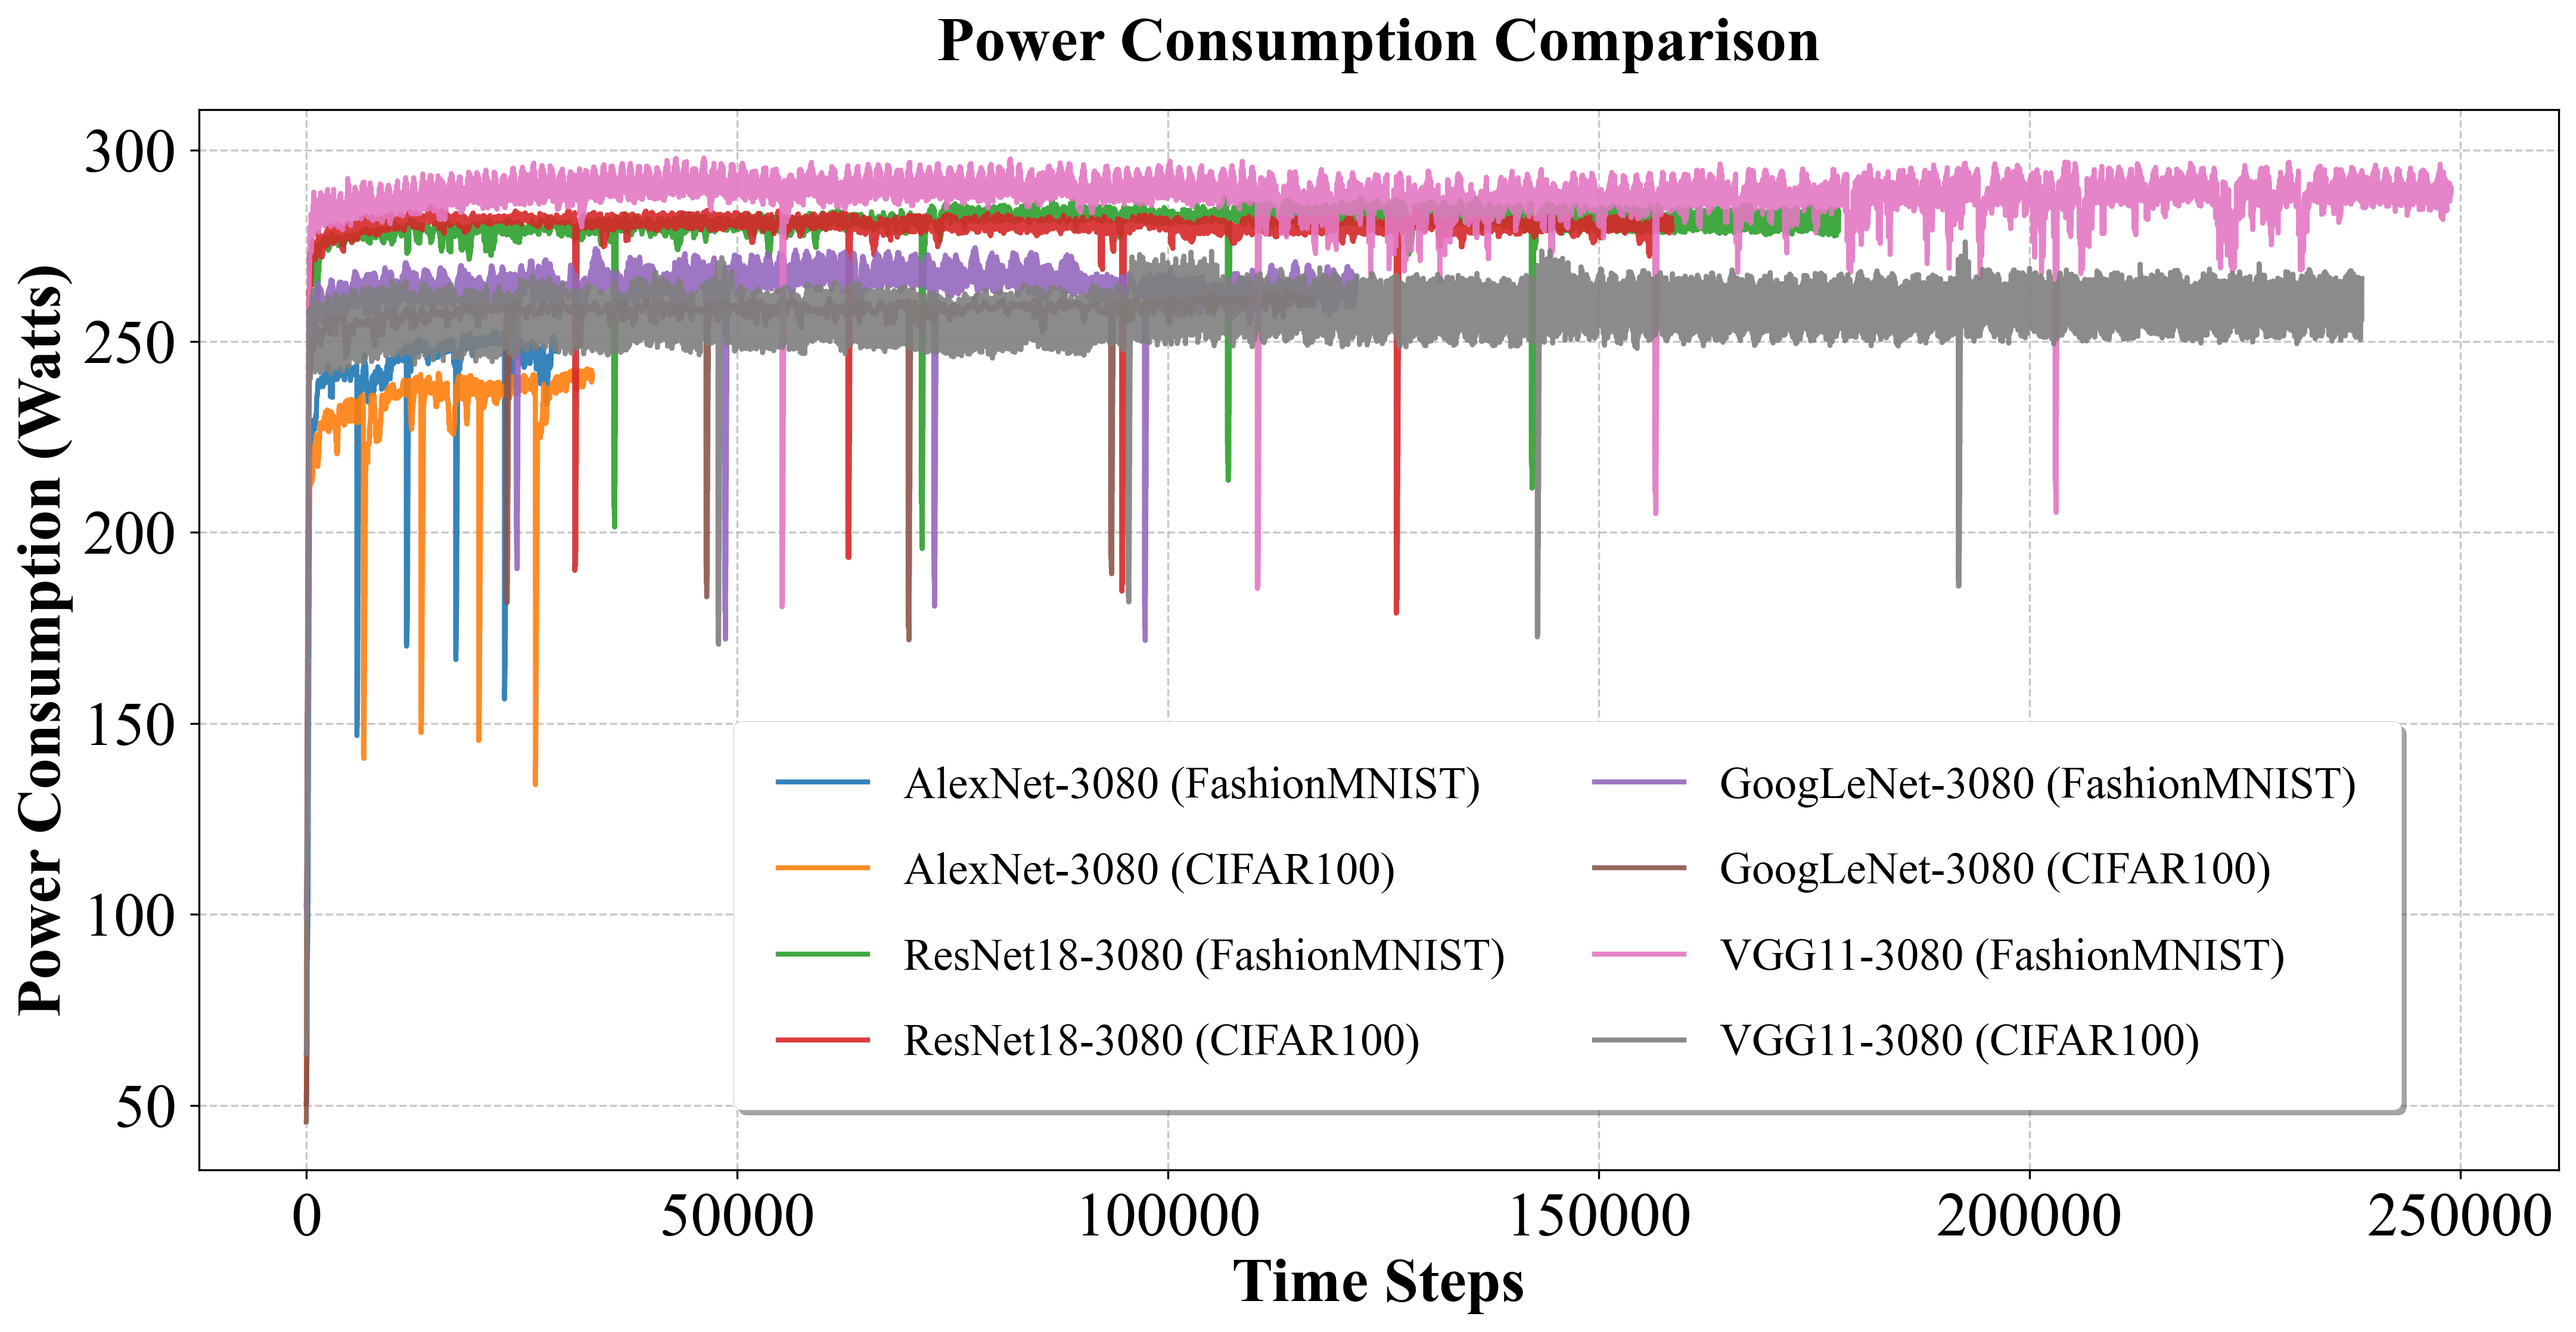

In [ ]:
# # Create a figure
# # plt.figure(figsize=(15,12))
# # Set the style for a professional look
# plt.style.use('seaborn-v0_8-paper')
# # Set all fonts to serif
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']  # Specify Times New Roman as the serif font
# plt.rcParams['font.size'] = 25
# plt.rcParams['axes.labelsize'] = 25 
# plt.rcParams['axes.titlesize'] = 25
# plt.rcParams['legend.fontsize'] = 18
# plt.rcParams['xtick.labelsize'] = 25
# plt.rcParams['ytick.labelsize'] = 25

# Create a figure with higher DPI for better quality
plt.figure(figsize=(15, 8), dpi=300)

# Plot data for 3080 models with improved styling
plt.plot(alexnet3080_f['power_in_watts'][:], label='AlexNet-3080 (FashionMNIST)', 
         color=colors[0], linewidth=2, alpha=0.9)
plt.plot(alexnet3080_c['power_in_watts'][:], label='AlexNet-3080 (CIFAR100)', 
         color=colors[1], linewidth=2, alpha=0.9)
plt.plot(resnet343080_f['power_in_watts'][:], label='ResNet18-3080 (FashionMNIST)', 
         color=colors[2], linewidth=2, alpha=0.9)
plt.plot(resnet343080_c['power_in_watts'][:], label='ResNet18-3080 (CIFAR100)', 
         color=colors[3], linewidth=2, alpha=0.9)
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='GoogLeNet-3080 (FashionMNIST)', 
         color=colors[4], linewidth=2, alpha=0.9)
plt.plot(googlenet_origin3080_c['power_in_watts'][:], label='GoogLeNet-3080 (CIFAR100)', 
         color=colors[5], linewidth=2, alpha=0.9)
plt.plot(vgg113080_f['power_in_watts'][:], label='VGG11-3080 (FashionMNIST)', 
         color=colors[6], linewidth=2, alpha=0.9)
plt.plot(vgg113080_c['power_in_watts'][:], label='VGG11-3080 (CIFAR100)', 
         color=colors[7], linewidth=2, alpha=0.9)

# Customize the plot with professional styling
plt.xlabel('Time Steps', fontweight='bold')
plt.ylabel('Power Consumption (Watts)', fontweight='bold')
plt.title('Power Consumption Comparison', 
          fontweight='bold', pad=20)

# Add grid with subtle styling
plt.grid(True, linestyle='--', alpha=0.7)

# Customize legend - moved to bottom center
plt.legend(loc='center', bbox_to_anchor=(0.58, 0.24),
          frameon=True, fancybox=True, shadow=True,
          borderpad=1, labelspacing=1, ncol=2)

# Adjust layout to prevent text cutoff
plt.tight_layout()

# Save the figure with high DPI
# plt.savefig('power_consumption_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.savefig('power_consumption_comparison.png', format='png', dpi=300, bbox_inches='tight')

plt.show()


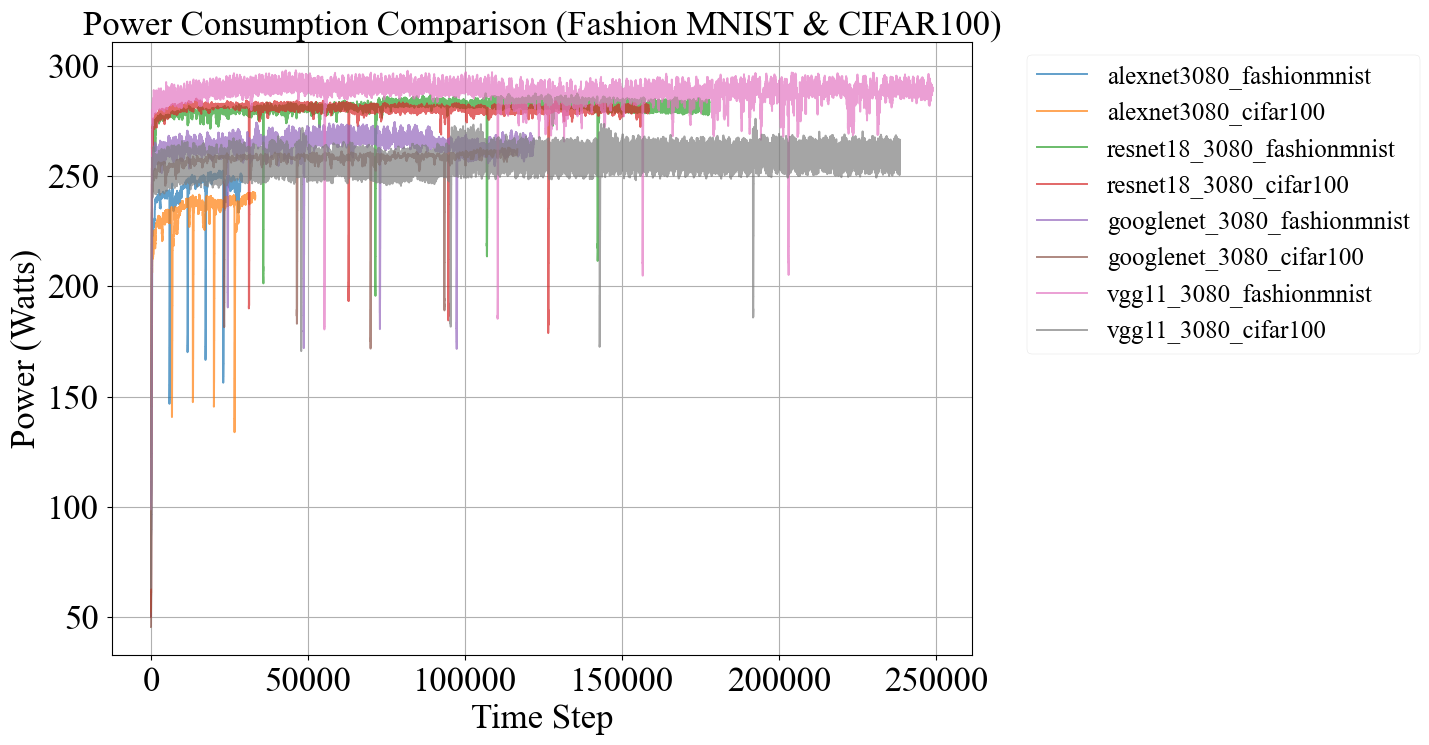

In [ ]:
plt.figure(figsize=(15, 8))

# Plot data for 3080 models
plt.plot(alexnet3080_f['power_in_watts'][:], label='alexnet3080_fashionmnist', alpha=0.7)
plt.plot(alexnet3080_c['power_in_watts'][:], label='alexnet3080_cifar100', alpha=0.7)
plt.plot(resnet343080_f['power_in_watts'][:], label='resnet18_3080_fashionmnist', alpha=0.7)
plt.plot(resnet343080_c['power_in_watts'][:], label='resnet18_3080_cifar100', alpha=0.7)
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='googlenet_3080_fashionmnist', alpha=0.7)
plt.plot(googlenet_origin3080_c['power_in_watts'][:], label='googlenet_3080_cifar100', alpha=0.7)
plt.plot(vgg113080_f['power_in_watts'][:], label='vgg11_3080_fashionmnist', alpha=0.7)
plt.plot(vgg113080_c['power_in_watts'][:], label='vgg11_3080_cifar100', alpha=0.7)
# plt.plot(mobilenetv23080_f['power_in_watts'][:], label='mobilenetv2_3080_fashionmnist', alpha=0.7)

# # Plot data for 4090 models with dashed lines
# plt.plot(alexnet4090_f['power_in_watts'][:41500], label='alexnet4090_fashionmnist', alpha=0.7, linestyle='--')
# plt.plot(alexnet4090_c['power_in_watts'][:50000], label='alexnet4090_cifar100', alpha=0.7, linestyle='--')


# Customize the plot
plt.xlabel('Time Step')
plt.ylabel('Power (Watts)')
plt.title('Power Consumption Comparison (Fashion MNIST & CIFAR100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout() 
plt.show()

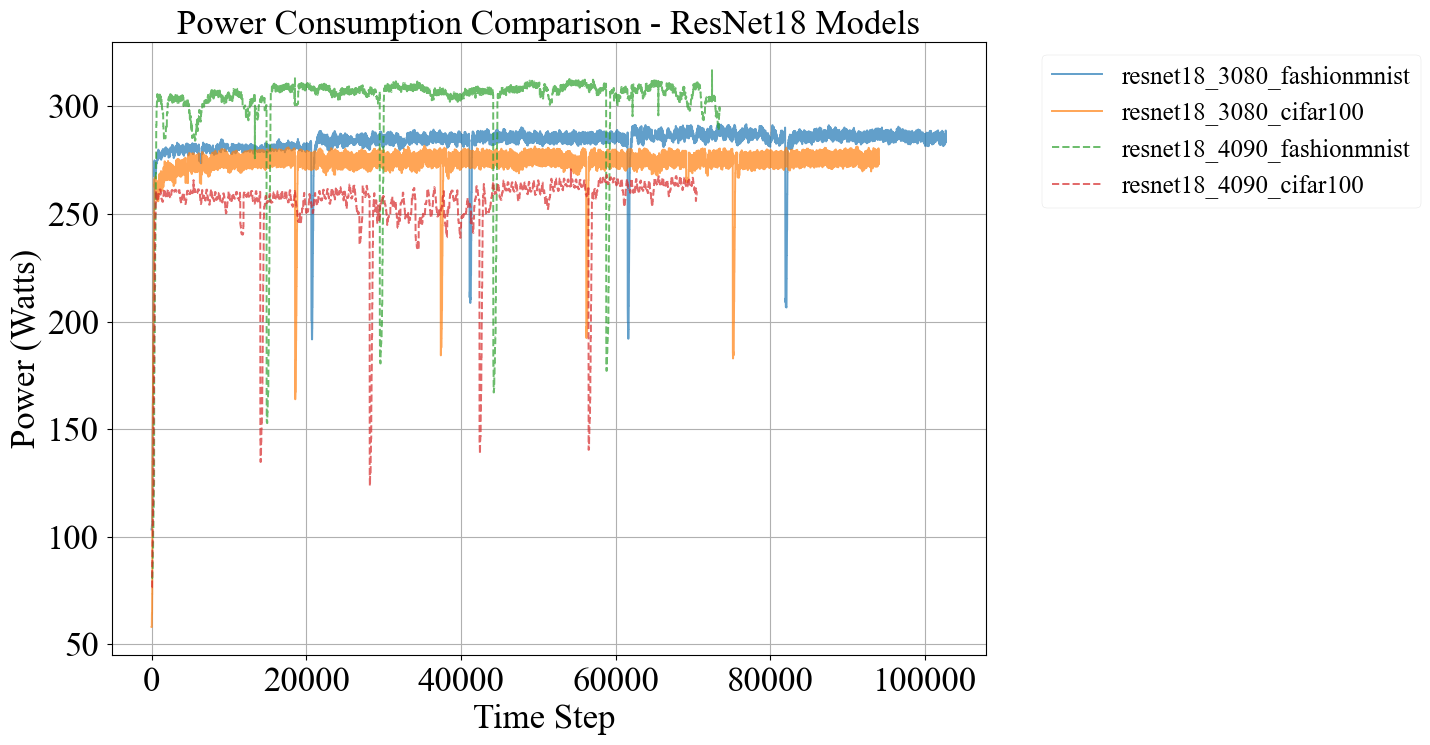

In [ ]:
# Create a figure
plt.figure(figsize=(15, 8))

# Plot data for 3080 models
plt.plot(resnet183080_f['power_in_watts'][:], label='resnet18_3080_fashionmnist', alpha=0.7)
plt.plot(resnet183080_c['power_in_watts'][:], label='resnet18_3080_cifar100', alpha=0.7)

# Plot data for 4090 models with dashed lines
plt.plot(resnet184090_f['power_in_watts'][:], label='resnet18_4090_fashionmnist', alpha=0.7, linestyle='--')
plt.plot(resnet184090_c['power_in_watts'][:], label='resnet18_4090_cifar100', alpha=0.7, linestyle='--')

# Customize the plot
plt.xlabel('Time Step ')
plt.ylabel('Power (Watts)')
plt.title('Power Consumption Comparison - ResNet18 Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


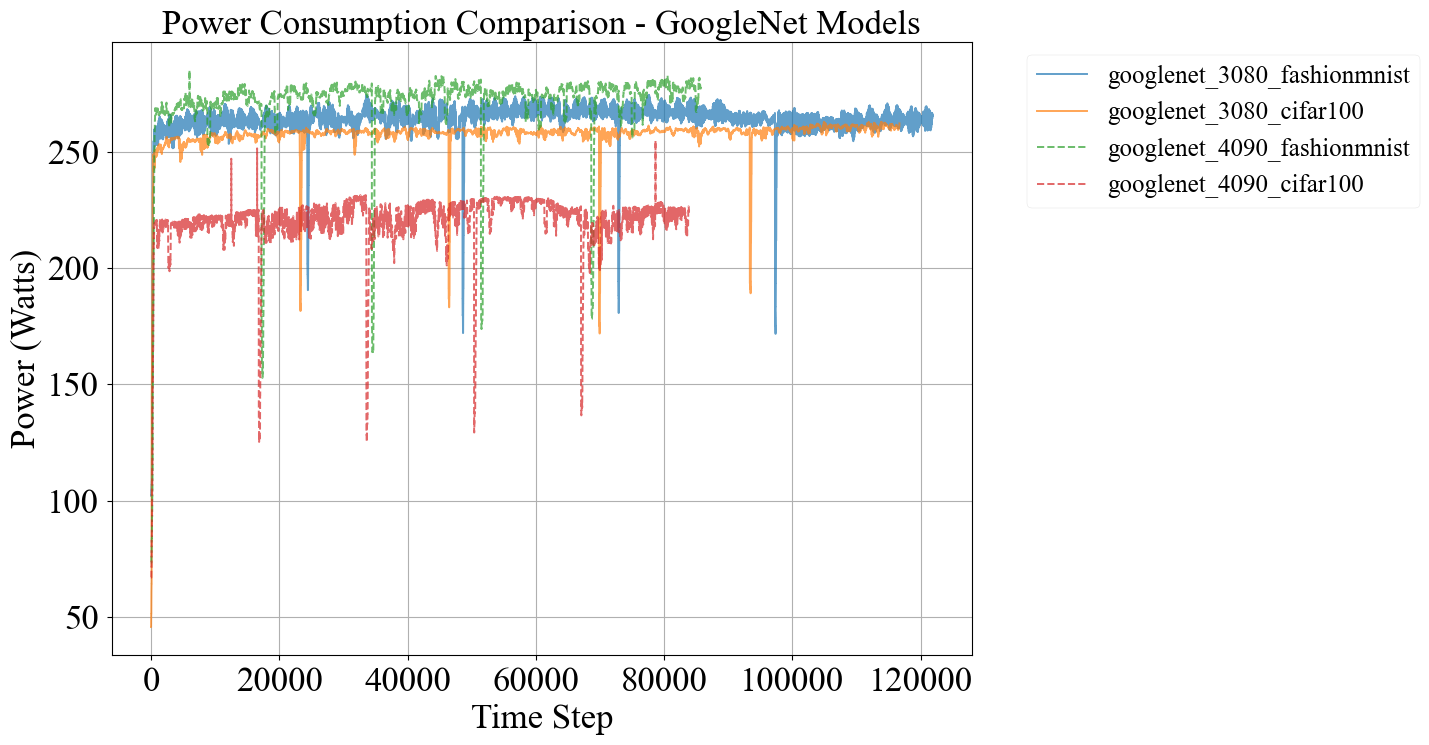

In [ ]:
# Create a figure
plt.figure(figsize=(15, 8))

# Plot data for 3080 models
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='googlenet_3080_fashionmnist', alpha=0.7)
plt.plot(googlenet_origin3080_c['power_in_watts'][:], label='googlenet_3080_cifar100', alpha=0.7)

# Plot data for 4090 models with dashed lines
plt.plot(googlenet_origin4090_f['power_in_watts'][:], label='googlenet_4090_fashionmnist', alpha=0.7, linestyle='--')
plt.plot(googlenet_origin4090_c['power_in_watts'][:], label='googlenet_4090_cifar100', alpha=0.7, linestyle='--')

# Customize the plot
plt.xlabel('Time Step')
plt.ylabel('Power (Watts)')
plt.title('Power Consumption Comparison - GoogleNet Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


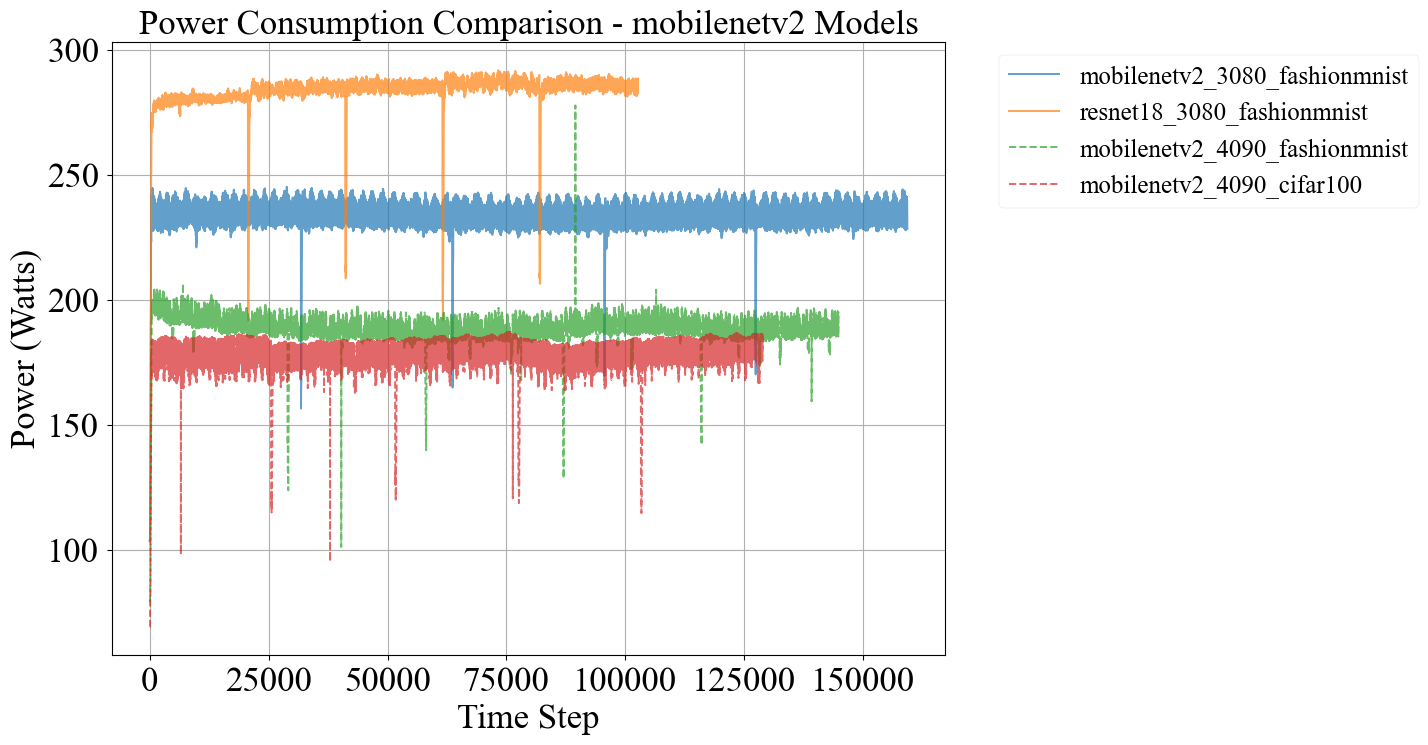

In [ ]:
# Create a figure
plt.figure(figsize=(15, 8))

# Plot data for 3080 models
plt.plot(mobilenetv23080_f['power_in_watts'][:], label='mobilenetv2_3080_fashionmnist', alpha=0.7)
plt.plot(resnet183080_f['power_in_watts'][:], label='resnet18_3080_fashionmnist', alpha=0.7)

# Plot data for 4090 models with dashed lines
plt.plot(mobilenetv24090_f['power_in_watts'][:], label='mobilenetv2_4090_fashionmnist', alpha=0.7, linestyle='--')
plt.plot(mobilenetv24090_c['power_in_watts'][:], label='mobilenetv2_4090_cifar100', alpha=0.7, linestyle='--')

# Customize the plot
plt.xlabel('Time Step')
plt.ylabel('Power (Watts)')
plt.title('Power Consumption Comparison - mobilenetv2 Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

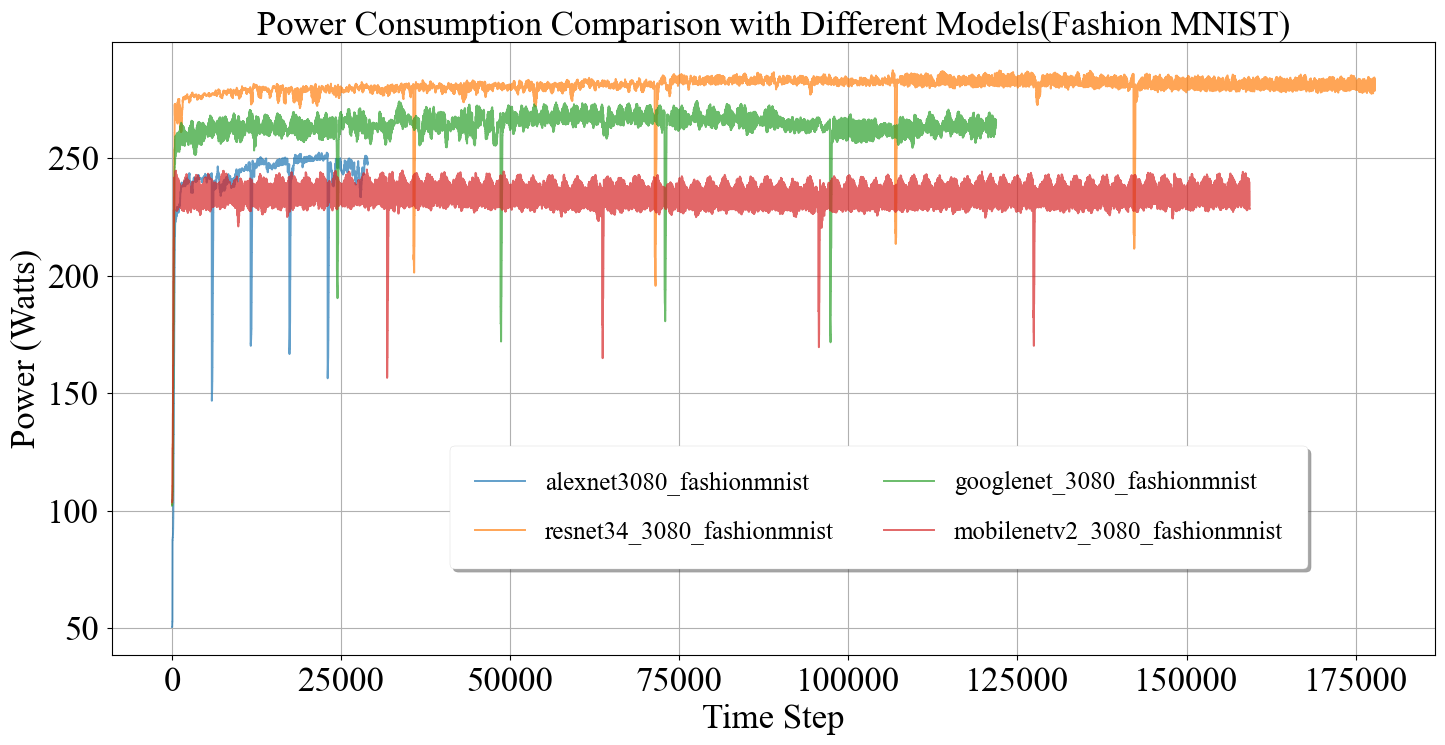

In [ ]:
# Create a figure
# Fig 2 
plt.figure(figsize=(15, 8))

# Plot data for 3080 models
plt.plot(alexnet3080_f['power_in_watts'][:], label='alexnet3080_fashionmnist', alpha=0.7)
plt.plot(resnet343080_f['power_in_watts'][:], label='resnet34_3080_fashionmnist', alpha=0.7)
plt.plot(googlenet_origin3080_f['power_in_watts'][:], label='googlenet_3080_fashionmnist', alpha=0.7)
plt.plot(mobilenetv23080_f['power_in_watts'][:], label='mobilenetv2_3080_fashionmnist', alpha=0.7)

# Customize the plot
plt.xlabel('Time Step')
plt.ylabel('Power (Watts)')
plt.title('Power Consumption Comparison with Different Models(Fashion MNIST)')
# Customize legend - moved to bottom center
plt.legend(loc='center', bbox_to_anchor=(0.58, 0.24),
          frameon=True, fancybox=True, shadow=True,
          borderpad=1, labelspacing=1, ncol=2)
plt.grid(True)

plt.tight_layout()
plt.show()


## Comparison of all the energy consumption data collected from 3080 and 4090

In [ ]:
def calculate_totalenergy(npyfile):
    energy = 0
    for epoch in range(npyfile.shape[0]):
        for batch in range(npyfile.shape[1]):
            energy += (npyfile[epoch][batch][1] - npyfile[epoch][batch][0]) * npyfile[epoch][batch][2]
    return energy


In [ ]:
# find all the data in the file3080_dir
modelslist = os.listdir(file3080_dir)
# create a dictionary to store the total energy for each model
total_energy_dict_f_3080 = {}
for model in modelslist:
    # get the data folder for each model
    datafolder = os.path.join(file3080_dir, model, dataset[0], sample_folder)
    # print(datafolder)
    # get the to_device_energy.npy, forward_energy.npy, loss_energy.npy, backward_energy.npy, optimize_energy.npy
    to_device_energy = np.load(os.path.join(datafolder, 'to_device_energy.npy'), allow_pickle=True)
    forward_energy = np.load(os.path.join(datafolder, 'forward_energy.npy'), allow_pickle=True)
    loss_energy = np.load(os.path.join(datafolder, 'loss_energy.npy'), allow_pickle=True)
    backward_energy = np.load(os.path.join(datafolder, 'backward_energy.npy'), allow_pickle=True)
    optimize_energy = np.load(os.path.join(datafolder, 'optimize_energy.npy'), allow_pickle=True)

    # calculate the total energy for each step, the shape is (5, 469, 3)
    to_device_totalenergy = calculate_totalenergy(to_device_energy)
    forward_totalenergy = calculate_totalenergy(forward_energy)
    loss_totalenergy = calculate_totalenergy(loss_energy)
    backward_totalenergy = calculate_totalenergy(backward_energy)
    optimize_totalenergy = calculate_totalenergy(optimize_energy)

    # total consumption energy
    total_energy = to_device_totalenergy + forward_totalenergy + loss_totalenergy + backward_totalenergy + optimize_totalenergy

    # store the total energy for each model
    total_energy_dict_f_3080[model] = total_energy

print(total_energy_dict_f_3080)

{'googlenet_origin': 6369.781229416533, 'resnet50': 10581.744209791215, 'resnet34': 15642.585051412809, 'mobilenetv2': 9095.863585598378, 'vgg13': 189606.95335206322, 'googlenet_mod7': 11311.688135393806, 'googlenet_mod9': 612.8297170117277, 'googlenet_mod8': 20239.913846635816, 'googlenet_mod1': 4203.496031620222, 'googlenet_mod6': 5485.586579400379, 'resnet18': 4995.363282606904, 'mobilenetv1': 1815.9795224899408, 'vit': 5866.942955963818, 'vgg16': 287872.58915847685, 'vgg11': 43143.818687905245, 'vgg19': 283542.6861115376, 'googlenet_mod3': 4198.589761037991, 'googlenet_mod4': 4165.539260468766, 'googlenet_mod5': 2236.4643704451178, 'googlenet_mod2': 1967.6826250417273, 'alexnet': 295.97153643742}


In [ ]:
# find all the data in the file3080_dir
modelslist = os.listdir(file3080_dir)
# create a dictionary to store the total energy for each model
total_energy_dict_c_3080 = {}
for model in modelslist:
    # get the data folder for each model
    datafolder = os.path.join(file3080_dir, model, dataset[1], sample_folder)
    # print(datafolder)
    # get the to_device_energy.npy, forward_energy.npy, loss_energy.npy, backward_energy.npy, optimize_energy.npy
    to_device_energy = np.load(os.path.join(datafolder, 'to_device_energy.npy'), allow_pickle=True)
    forward_energy = np.load(os.path.join(datafolder, 'forward_energy.npy'), allow_pickle=True)
    loss_energy = np.load(os.path.join(datafolder, 'loss_energy.npy'), allow_pickle=True)
    backward_energy = np.load(os.path.join(datafolder, 'backward_energy.npy'), allow_pickle=True)
    optimize_energy = np.load(os.path.join(datafolder, 'optimize_energy.npy'), allow_pickle=True)

    # calculate the total energy for each step, the shape is (5, 469, 3)
    to_device_totalenergy = calculate_totalenergy(to_device_energy)
    forward_totalenergy = calculate_totalenergy(forward_energy)
    loss_totalenergy = calculate_totalenergy(loss_energy)
    backward_totalenergy = calculate_totalenergy(backward_energy)
    optimize_totalenergy = calculate_totalenergy(optimize_energy)

    # total consumption energy
    total_energy = to_device_totalenergy + forward_totalenergy + loss_totalenergy + backward_totalenergy + optimize_totalenergy

    # store the total energy for each model
    total_energy_dict_c_3080[model] = total_energy

print(total_energy_dict_c_3080)

{'googlenet_origin': 5891.637167761389, 'resnet50': 9451.735848029926, 'resnet34': 13619.78180653549, 'mobilenetv2': 16754.398666789246, 'vgg13': 171429.3962756959, 'googlenet_mod7': 9860.901478997079, 'googlenet_mod9': 705.4852040518023, 'googlenet_mod8': 17325.43437565124, 'googlenet_mod1': 3969.9795914654223, 'googlenet_mod6': 4963.2246856042875, 'resnet18': 4515.226129508075, 'mobilenetv1': 1490.349492291362, 'vit': 5148.808979352324, 'vgg16': 243172.3573257249, 'vgg11': 41048.05634844155, 'vgg19': 313777.1684361614, 'googlenet_mod3': 3924.785779313404, 'googlenet_mod4': 3810.0770148649563, 'googlenet_mod5': 2145.46847033542, 'googlenet_mod2': 1961.5040928073824, 'alexnet': 370.34955116671995}


In [ ]:
# find all the data in the file3080_dir
modelslist = os.listdir(file4090_dir)
# create a dictionary to store the total energy for each model
total_energy_dict_f_4090 = {}
for model in modelslist:
    # get the data folder for each model
    datafolder = os.path.join(file4090_dir, model, dataset[0], sample_folder)
    # print(datafolder)
    # get the to_device_energy.npy, forward_energy.npy, loss_energy.npy, backward_energy.npy, optimize_energy.npy
    to_device_energy = np.load(os.path.join(datafolder, 'to_device_energy.npy'), allow_pickle=True)
    forward_energy = np.load(os.path.join(datafolder, 'forward_energy.npy'), allow_pickle=True)
    loss_energy = np.load(os.path.join(datafolder, 'loss_energy.npy'), allow_pickle=True)
    backward_energy = np.load(os.path.join(datafolder, 'backward_energy.npy'), allow_pickle=True)
    optimize_energy = np.load(os.path.join(datafolder, 'optimize_energy.npy'), allow_pickle=True)

    # calculate the total energy for each step, the shape is (5, 469, 3)
    to_device_totalenergy = calculate_totalenergy(to_device_energy)
    forward_totalenergy = calculate_totalenergy(forward_energy)
    loss_totalenergy = calculate_totalenergy(loss_energy)
    backward_totalenergy = calculate_totalenergy(backward_energy)
    optimize_totalenergy = calculate_totalenergy(optimize_energy)

    # total consumption energy
    total_energy = to_device_totalenergy + forward_totalenergy + loss_totalenergy + backward_totalenergy + optimize_totalenergy

    # store the total energy for each model
    total_energy_dict_f_4090[model] = total_energy

print(total_energy_dict_f_4090)

{'googlenet_origin': 1786.501458015134, 'resnet50': 3058.2385294083792, 'resnet34': 4234.080178224608, 'mobilenetv2': 2948.092238449492, 'vgg13': 32433.906223080536, 'googlenet_mod7': 2796.824799310735, 'googlenet_mod9': 173.60946316787167, 'googlenet_mod8': 4572.93484351415, 'googlenet_mod1': 1171.2336304644773, 'googlenet_mod6': 1329.591261897074, 'resnet18': 1429.3394767059735, 'mobilenetv1': 555.7766452651066, 'vit': 1163.5128534140645, 'vgg16': 50345.313649015945, 'vgg11': 9887.892249310278, 'vgg19': 59745.5231118886, 'googlenet_mod3': 1198.6234969822397, 'googlenet_mod4': 1153.3612960539313, 'googlenet_mod5': 535.9058753698843, 'googlenet_mod2': 649.6154270198858, 'alexnet': 66.24352419913328}


In [ ]:
# find all the data in the file3080_dir
modelslist = os.listdir(file4090_dir)
# create a dictionary to store the total energy for each model
total_energy_dict_c_4090 = {}
for model in modelslist:
    # get the data folder for each model
    datafolder = os.path.join(file4090_dir, model, dataset[1], sample_folder)
    # print(datafolder)
    # get the to_device_energy.npy, forward_energy.npy, loss_energy.npy, backward_energy.npy, optimize_energy.npy
    to_device_energy = np.load(os.path.join(datafolder, 'to_device_energy.npy'), allow_pickle=True)
    forward_energy = np.load(os.path.join(datafolder, 'forward_energy.npy'), allow_pickle=True)
    loss_energy = np.load(os.path.join(datafolder, 'loss_energy.npy'), allow_pickle=True)
    backward_energy = np.load(os.path.join(datafolder, 'backward_energy.npy'), allow_pickle=True)
    optimize_energy = np.load(os.path.join(datafolder, 'optimize_energy.npy'), allow_pickle=True)

    # calculate the total energy for each step, the shape is (5, 469, 3)
    to_device_totalenergy = calculate_totalenergy(to_device_energy)
    forward_totalenergy = calculate_totalenergy(forward_energy)
    loss_totalenergy = calculate_totalenergy(loss_energy)
    backward_totalenergy = calculate_totalenergy(backward_energy)
    optimize_totalenergy = calculate_totalenergy(optimize_energy)

    # total consumption energy
    total_energy = to_device_totalenergy + forward_totalenergy + loss_totalenergy + backward_totalenergy + optimize_totalenergy

    # store the total energy for each model
    total_energy_dict_c_4090[model] = total_energy

print(total_energy_dict_c_4090)

{'googlenet_origin': 1350.2128178635114, 'resnet50': 2392.143157262473, 'resnet34': 3260.289973299544, 'mobilenetv2': 2274.633282849414, 'vgg13': 44078.43957339062, 'googlenet_mod7': 2045.5489968704414, 'googlenet_mod9': 181.72837657140346, 'googlenet_mod8': 3590.082349936043, 'googlenet_mod1': 919.8978980630071, 'googlenet_mod6': 1034.2835041557291, 'resnet18': 1104.3546886345705, 'mobilenetv1': 429.7022264748654, 'vit': 1011.8942107834763, 'vgg16': 60785.606590462456, 'vgg11': 8162.5227758551155, 'vgg19': 46198.656971650846, 'googlenet_mod3': 874.8121883690416, 'googlenet_mod4': 883.2345503629475, 'googlenet_mod5': 442.9260471863092, 'googlenet_mod2': 532.8277489602089, 'alexnet': 86.74792351007186}


In [ ]:
# read the macs_paras.csv file for each model
macs_paras = pd.read_csv(os.path.join(parent_dir, '3080/macs_paras.csv'))
print(macs_paras)
macs_models = macs_paras['Model']
macs_paras_fashionmnist = macs_paras['MACs_f']
macs_paras_cifar100 = macs_paras['MACs_c100']
model_macs_fashionmnist = []
for i in macs_paras_fashionmnist:
    unit = i.split(' ')[1][0]
    value = float(i.split(' ')[0])
    if unit == 'M':
        macs_paras_fashionmnist[i] = value * 1e6
    elif unit == 'G':
        macs_paras_fashionmnist[i] = value * 1e9
    model_macs_fashionmnist.append(macs_paras_fashionmnist[i])

model_macs_cifar100 = []
for i in macs_paras_cifar100:
    unit = i.split(' ')[1][0]
    value = float(i.split(' ')[0])
    if unit == 'M':
        macs_paras_cifar100[i] = value * 1e6
    elif unit == 'G':
        macs_paras_cifar100[i] = value * 1e9
    model_macs_cifar100.append(macs_paras_cifar100[i])

print(model_macs_fashionmnist, model_macs_cifar100)

             Model       MACs_f Parameters_f    MACs_c100 Parameters_c100  \
0          alexnet  666.41 MMac      57.03 M  713.63 MMac         57.41 M   
1         resnet18    1.75 GMac      11.18 M    1.83 GMac         11.23 M   
2         resnet34    3.61 GMac      21.29 M    3.68 GMac         21.34 M   
3         resnet50    2.32 GMac      13.87 M     2.4 GMac         13.92 M   
4            vgg11     7.6 GMac     128.81 M    7.65 GMac        129.18 M   
5            vgg13   11.31 GMac     128.99 M   11.37 GMac        129.36 M   
6            vgg16   15.48 GMac      134.3 M   15.54 GMac        134.67 M   
7            vgg19   19.63 GMac     139.61 M   19.69 GMac        139.98 M   
8        googlenet    1.52 GMac       5.98 M     1.6 GMac          6.08 M   
9   googlenet_mod1    1.32 GMac       4.61 M     1.4 GMac          4.67 M   
10  googlenet_mod2  682.58 MMac       5.03 M  761.31 MMac          5.09 M   
11  googlenet_mod3    1.32 GMac       4.94 M     1.4 GMac          5.03 M   

In [ ]:
energy_consumption_f3080 = np.zeros(len(macs_models))
energy_consumption_c3080 = np.zeros(len(macs_models))
energy_consumption_f4090 = np.zeros(len(macs_models))
energy_consumption_c4090 = np.zeros(len(macs_models))
# go through each dictionary of total_energy_dict_f_3080, total_energy_dict_c_3080, total_energy_dict_f_4090, total_energy_dict_c_4090, 
# if the model name match the macs_models, add the total energy to the energy_consumption list

for model in total_energy_dict_f_3080.keys():
    print(model)
    model_energy_consumption_3080_f = total_energy_dict_f_3080[model]
    model_energy_consumption_3080_c = total_energy_dict_c_3080[model]
    model_energy_consumption_4090_f = total_energy_dict_f_4090[model]
    model_energy_consumption_4090_c = total_energy_dict_c_4090[model]
    print(model_energy_consumption_3080_f, model_energy_consumption_3080_c, model_energy_consumption_4090_f, model_energy_consumption_4090_c)
    for i in range(len(macs_models)):
        namei = macs_models[i]
        if namei == model:
            energy_consumption_f3080[i] = model_energy_consumption_3080_f
            energy_consumption_c3080[i] = model_energy_consumption_3080_c
            energy_consumption_f4090[i] = model_energy_consumption_4090_f
            energy_consumption_c4090[i] = model_energy_consumption_4090_c

print(energy_consumption_f3080, energy_consumption_c3080, energy_consumption_f4090, energy_consumption_c4090)

googlenet_origin
6369.781229416533 5891.637167761389 1786.501458015134 1350.2128178635114
resnet50
10581.744209791215 9451.735848029926 3058.2385294083792 2392.143157262473
resnet34
15642.585051412809 13619.78180653549 4234.080178224608 3260.289973299544
mobilenetv2
9095.863585598378 16754.398666789246 2948.092238449492 2274.633282849414
vgg13
189606.95335206322 171429.3962756959 32433.906223080536 44078.43957339062
googlenet_mod7
11311.688135393806 9860.901478997079 2796.824799310735 2045.5489968704414
googlenet_mod9
612.8297170117277 705.4852040518023 173.60946316787167 181.72837657140346
googlenet_mod8
20239.913846635816 17325.43437565124 4572.93484351415 3590.082349936043
googlenet_mod1
4203.496031620222 3969.9795914654223 1171.2336304644773 919.8978980630071
googlenet_mod6
5485.586579400379 4963.2246856042875 1329.591261897074 1034.2835041557291
resnet18
4995.363282606904 4515.226129508075 1429.3394767059735 1104.3546886345705
mobilenetv1
1815.9795224899408 1490.349492291362 555.7

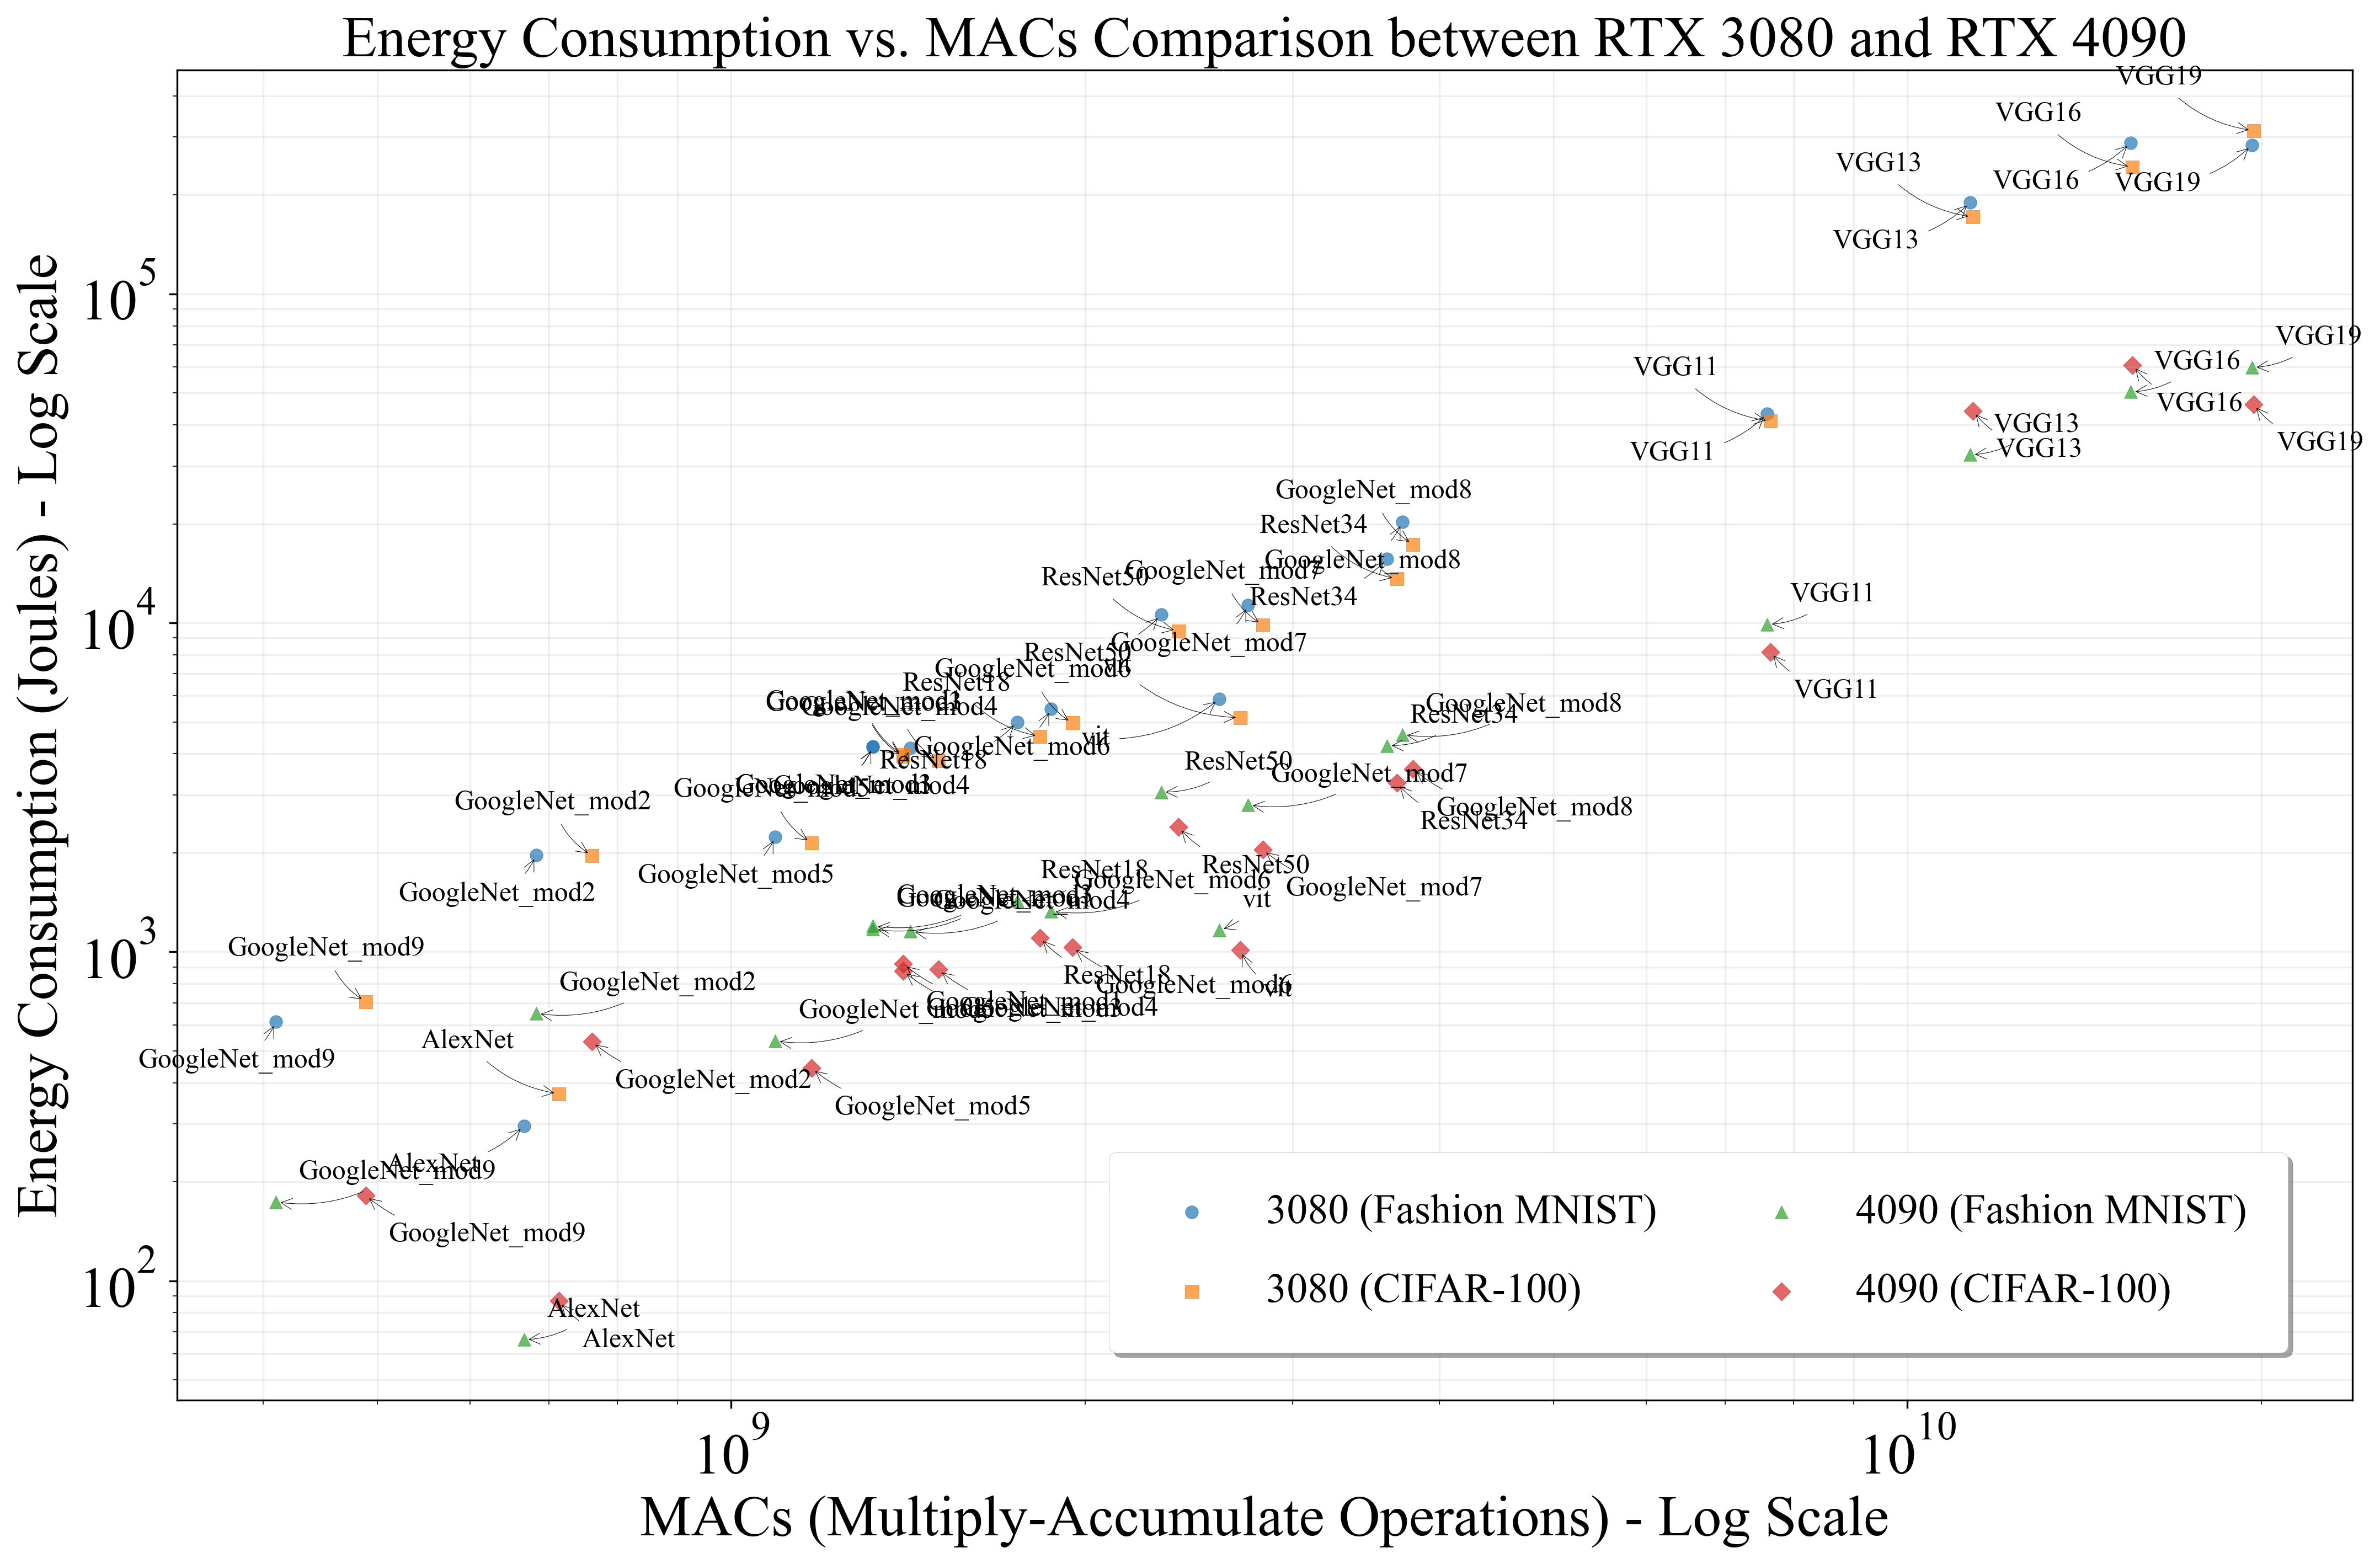

In [ ]:
plt.figure(figsize=(15, 10), dpi=300)

# Create scatter plots for 3080
plt.scatter(model_macs_fashionmnist, energy_consumption_f3080, label='3080 (Fashion MNIST)', marker='o', alpha=0.7)
plt.scatter(model_macs_cifar100, energy_consumption_c3080, label='3080 (CIFAR-100)', marker='s', alpha=0.7)

# Create scatter plots for 4090
plt.scatter(model_macs_fashionmnist, energy_consumption_f4090, label='4090 (Fashion MNIST)', marker='^', alpha=0.7)
plt.scatter(model_macs_cifar100, energy_consumption_c4090, label='4090 (CIFAR-100)', marker='D', alpha=0.7)

# Add annotations for all points with adjusted offsets to prevent overlap
offsets = [(-60, -20), (10, 10), (-60, 20), (10, -20)]  # Different offsets for each point type
for i, model in enumerate(macs_models):
    # Replace model names with proper capitalization
    label = (model.replace('alexnet', 'AlexNet')
                 .replace('googlenet', 'GoogleNet')
                 .replace('resnet', 'ResNet')
                 .replace('vgg', 'VGG'))
    
    # Label Fashion MNIST points with different offsets
    plt.annotate(label, 
                (model_macs_fashionmnist[i], energy_consumption_f3080[i]),
                xytext=offsets[0], 
                textcoords='offset points',
                fontsize=12,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))
    plt.annotate(label, 
                (model_macs_fashionmnist[i], energy_consumption_f4090[i]),
                xytext=offsets[1], 
                textcoords='offset points',
                fontsize=12,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.2'))
    
    # Label CIFAR-100 points with different offsets
    plt.annotate(label, 
                (model_macs_cifar100[i], energy_consumption_c3080[i]),
                xytext=offsets[2], 
                textcoords='offset points',
                fontsize=12,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))
    plt.annotate(label, 
                (model_macs_cifar100[i], energy_consumption_c4090[i]),
                xytext=offsets[3], 
                textcoords='offset points',
                fontsize=12,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.2'))

plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale

plt.xlabel('MACs (Multiply-Accumulate Operations) - Log Scale')
plt.ylabel('Energy Consumption (Joules) - Log Scale')
plt.title('Energy Consumption vs. MACs Comparison between RTX 3080 and RTX 4090')
plt.grid(True, which="both", ls="-", alpha=0.2)
# Customize legend - moved to bottom right
plt.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02),
          frameon=True, fancybox=True, shadow=True,
          borderpad=1, labelspacing=1, ncol=2)
plt.tight_layout()

KeyError: 'vgg19'

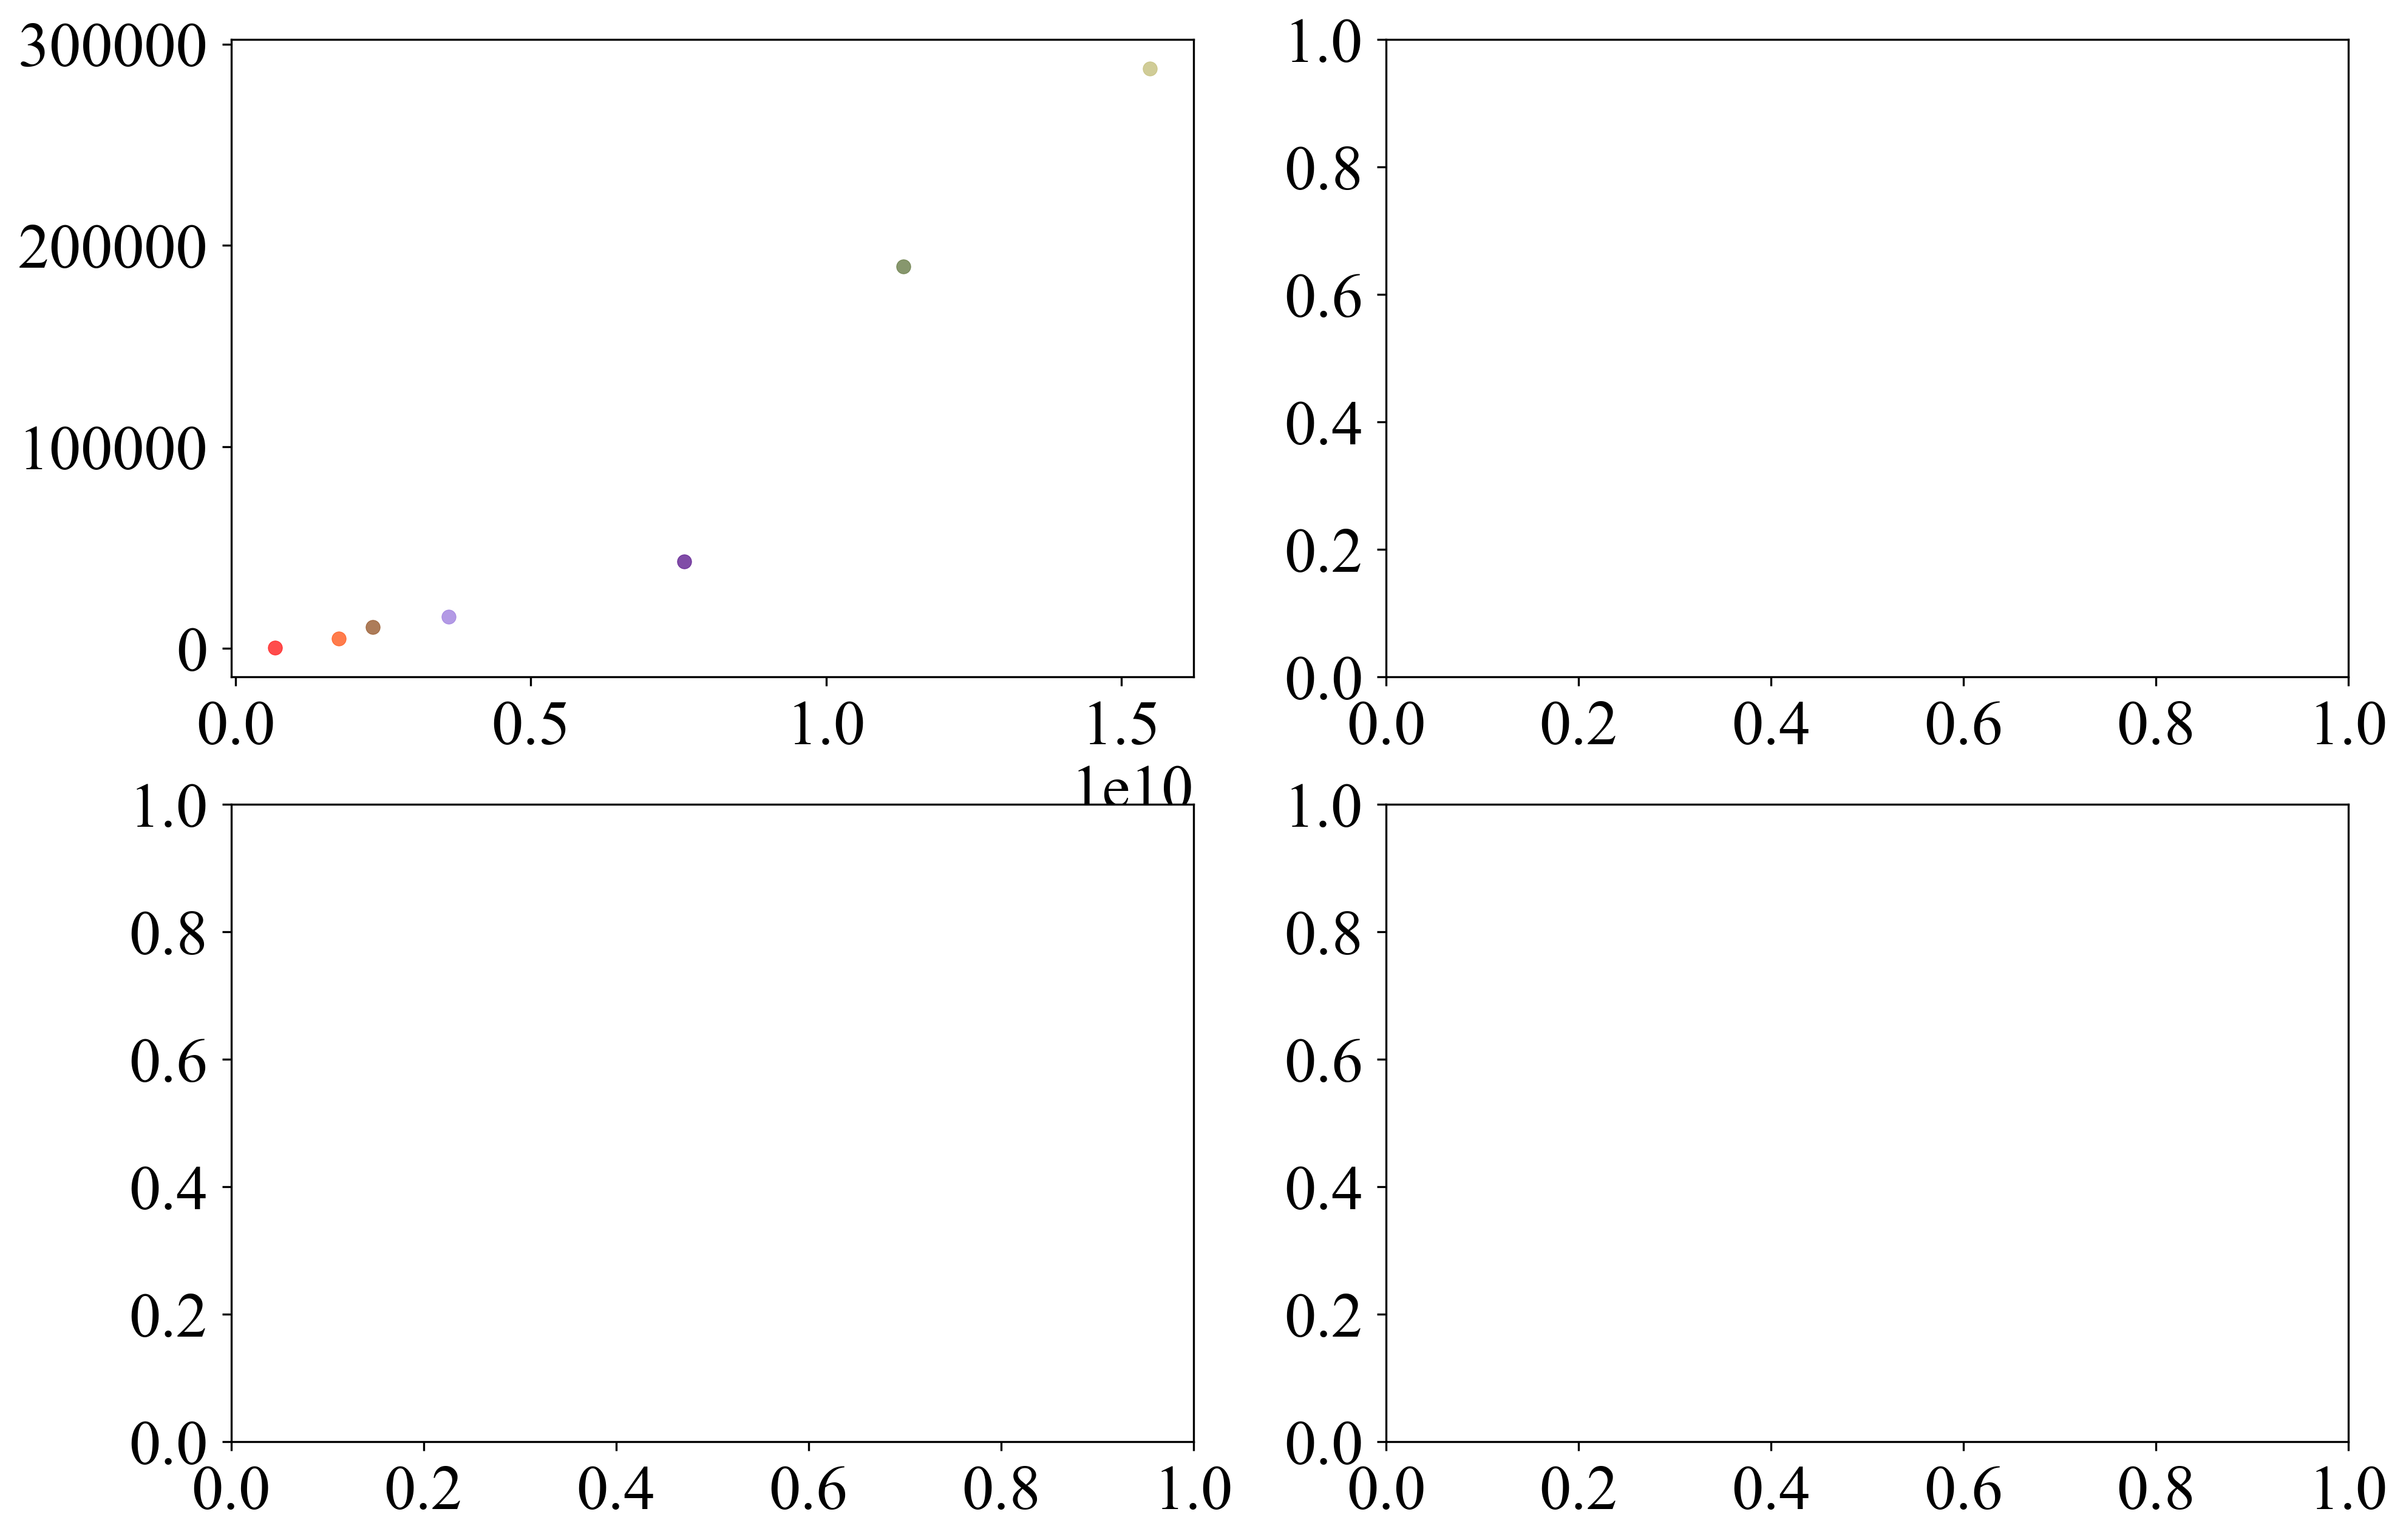

In [ ]:
# Create a 2x2 subplot figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10), dpi=300)

# Define colors for each model
model_colors = {
    'alexnet': '#FF0000',           # Red
    'googlenet': '#00FFFF',  # Cyan
    'googlenet_mod1': '#0000FF',    # Blue
    'googlenet_mod2': '#00FF00',    # Green
    'googlenet_mod3': '#FFD700',    # Gold
    'googlenet_mod4': '#800080',    # Purple
    'googlenet_mod5': '#FFA500',    # Orange
    'googlenet_mod6': '#A52A2A',    # Brown
    'googlenet_mod7': '#808000',    # Olive
    'googlenet_mod8': '#FF69B4',    # Hot Pink
    'googlenet_mod9': '#696969',    # Dim Gray
    'resnet18': '#FF4500',          # Orange Red
    'resnet34': '#9370DB',          # Medium Purple
    'mobilenetv2': '#FF1493',       # Deep Pink
    'mobilenetv1': '#A9A9A9',       # Dark Gray
    'resnet50': '#8B4513',          # Saddle Brown
    'vgg13': '#556B2F',             # Dark Olive Green
    'vgg16': '#BDB76B',             # Dark Khaki
    'vgg11': '#4B0082'              # Indigo
}

# Figure 1: RTX 3080 with Fashion MNIST
for i, model in enumerate(macs_models):
    label = (model.replace('alexnet', 'AlexNet')
                 .replace('googlenet', 'GoogleNet')
                 .replace('resnet', 'ResNet')
                 .replace('vgg', 'VGG')
                 .replace('mobilenetv1', 'MobileNetV1')
                 .replace('mobilenetv2', 'MobileNetV2'))
    ax1.scatter(model_macs_fashionmnist[i], energy_consumption_f3080[i], 
                label=label if ax1 == ax1 else "", # Only add label in first plot
                color=model_colors[model.lower()], # model.lower() will match dictionary key
                marker='o', 
                alpha=0.7)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('MACs - Log Scale')
ax1.set_ylabel('Energy Consumption (Joules)')
ax1.set_title('RTX 3080 with Fashion MNIST')
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Figure 2: RTX 3080 with CIFAR-100
for i, model in enumerate(macs_models):
    ax2.scatter(model_macs_cifar100[i], energy_consumption_c3080[i],
                color=model_colors[model.lower()],
                marker='s', 
                alpha=0.7)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('MACs - Log Scale')
ax2.set_ylabel('Energy Consumption (Joules)')
ax2.set_title('RTX 3080 with CIFAR-100')
ax2.grid(True, which="both", ls="-", alpha=0.2)

# Figure 3: RTX 4090 with Fashion MNIST
for i, model in enumerate(macs_models):
    ax3.scatter(model_macs_fashionmnist[i], energy_consumption_f4090[i],
                color=model_colors[model.lower()],
                marker='^', 
                alpha=0.7)

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('MACs - Log Scale')
ax3.set_ylabel('Energy Consumption (Joules)')
ax3.set_title('RTX 4090 with Fashion MNIST')
ax3.grid(True, which="both", ls="-", alpha=0.2)

# Figure 4: RTX 4090 with CIFAR-100
for i, model in enumerate(macs_models):
    ax4.scatter(model_macs_cifar100[i], energy_consumption_c4090[i],
                color=model_colors[model.lower()],
                marker='D', 
                alpha=0.7)

ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_xlabel('MACs - Log Scale')
ax4.set_ylabel('Energy Consumption (Joules)')
ax4.set_title('RTX 4090 with CIFAR-100')
ax4.grid(True, which="both", ls="-", alpha=0.2)

# Add a unified legend at the bottom
plt.figlegend(ax1.get_legend_handles_labels()[0], 
              ax1.get_legend_handles_labels()[1],
              loc='center',
              bbox_to_anchor=(0.5, -0.1),
              ncol=4)

plt.suptitle('Energy Consumption vs. MACs Comparison of Different Models', y=1.02)
plt.tight_layout()

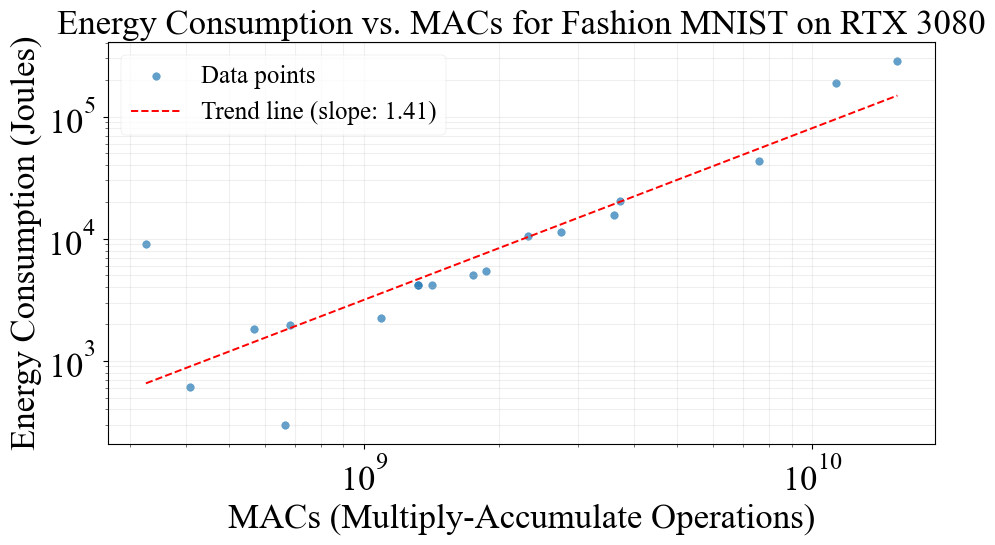

In [ ]:
# Create figure
plt.figure(figsize=(10, 6))

# Create scatter plot
plt.scatter(model_macs_fashionmnist, energy_consumption_f3080, alpha=0.7, label='Data points')

# Create line of best fit
# Convert arrays to numpy arrays and remove any zero values
x = np.array(model_macs_fashionmnist)
y = np.array(energy_consumption_f3080)
mask = (x > 0) & (y > 0)  # Only use positive values
x = x[mask]
y = y[mask]

# Perform the fit on log-transformed data
z = np.polyfit(np.log10(x), np.log10(y), 1)
p = np.poly1d(z)

# Generate points for the line
x_range = np.logspace(np.log10(min(x)), np.log10(max(x)), 100)
y_range = 10**p(np.log10(x_range))

# Plot the line
plt.plot(x_range, y_range, 'r--', label=f'Trend line (slope: {z[0]:.2f})')

# Set scales to logarithmic
plt.xscale('log')
plt.yscale('log')

# Add labels and title
plt.xlabel('MACs (Multiply-Accumulate Operations)')
plt.ylabel('Energy Consumption (Joules)')
plt.title('Energy Consumption vs. MACs for Fashion MNIST on RTX 3080')

# Add legend
plt.legend()

# Add grid
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
